# Week 5: ML/DL for Biomedical Signals — ECG, EEG, PSG
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Describe ECG, EEG, and PSG signal characteristics and their clinical significance
2. Implement signal preprocessing: filtering, R-peak detection, artifact removal
3. Extract time-domain, frequency-domain, and wavelet features from biomedical signals
4. Train and evaluate a 1D-CNN for ECG classification using simulated/PTB-XL data
5. Compare traditional ML (feature-based) vs deep learning (end-to-end) approaches

**Tools:** Google Colab + Gemini AI
**Dataset:** PTB-XL ECG Database (subset) via wfdb, with NeuroKit2 synthetic fallback
**Estimated Time:** 40-50 minutes

---

> **Clinical Scenario (Red Thread):** An EMT's ambulance is rushing through Tainan traffic.
> The patient clutches his chest — classic signs, but is it a STEMI that needs immediate
> catheterization, or non-cardiac chest pain? A portable 12-lead ECG connects to a tablet.
> Within 12 seconds, an AI algorithm analyzes the waveform and flashes: "STEMI detected —
> anterior wall." The EMT hits one button — the nearest cath lab is auto-alerted, the team
> is scrubbing in before the ambulance arrives. Those 30 minutes saved = surviving heart
> muscle. Today we build the signal processing and ML pipeline that makes this possible.


## 0. Environment Setup

We need two key signal processing libraries beyond Colab defaults:
- **neurokit2**: ECG/EEG/EMG signal processing — cleaning, peak detection, HRV analysis
- **wfdb**: Read PhysioNet WFDB-format records (PTB-XL, MIT-BIH, etc.)
- Pre-installed: numpy, pandas, matplotlib, scipy, sklearn, tensorflow/keras


In [1]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
!pip install neurokit2 wfdb --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 29.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Signal processing
import neurokit2 as nk
import wfdb
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, accuracy_score,
                             ConfusionMatrixDisplay)

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Print versions
print("All libraries loaded successfully!")
print(f"NumPy:       {np.__version__}")
print(f"Pandas:      {pd.__version__}")
print(f"NeuroKit2:   {nk.__version__}")
print(f"TensorFlow:  {tf.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"SciPy:       {__import__('scipy').__version__}")

# GPU check
if tf.config.list_physical_devices('GPU'):
    print(f"\nGPU available: {tf.config.list_physical_devices('GPU')[0].name}")
else:
    print("\nNo GPU detected — training will use CPU (still works for this notebook).")


All libraries loaded successfully!
NumPy:       2.0.2
Pandas:      2.3.3
NeuroKit2:   0.2.13
TensorFlow:  2.19.0
Scikit-learn: 1.6.1
SciPy:       1.16.3

No GPU detected — training will use CPU (still works for this notebook).


## 1. Load ECG Data

We attempt to load a real 12-lead ECG from the **PTB-XL** database (21,799 clinical
ECG recordings, the largest public clinical ECG dataset). If the download fails
(network issues, Colab restrictions), we fall back to **NeuroKit2's ECG simulator**
which generates realistic synthetic ECGs.

**Clinical Context:** Each ECG recording captures 10 seconds of the heart's electrical
activity across 12 different "camera angles" (leads). The EMT's tablet processes
exactly this kind of data — 5000 samples at 500 Hz sampling rate.

> **Corresponds to Slides S34 (Lab 1 Step 1)**


In [3]:
# ============================================================
# Section 1: Load ECG Data — PTB-XL with synthetic fallback
# ============================================================
USE_SYNTHETIC = False  # Will be set to True if PTB-XL fails

try:
    # Attempt to load a single PTB-XL record via PhysioNet
    print("Attempting to load PTB-XL ECG from PhysioNet...")
    record = wfdb.rdrecord('ptb-xl/records500/00000/00001_hr',
                           pn_dir='ptb-xl/1.0.3',
                           sampfrom=0, sampto=5000)
    ecg_data = record.p_signal          # shape: (5000, 12)
    sampling_rate = record.fs            # 500 Hz
    lead_names = record.sig_name         # ['I','II','III','aVR','aVL','aVF','V1',...,'V6']
    print(f"PTB-XL record loaded successfully!")
    print(f"  Signal shape: {ecg_data.shape} (samples x leads)")
    print(f"  Sampling rate: {sampling_rate} Hz")
    print(f"  Leads: {lead_names}")

except Exception as e:
    print(f"Could not load PTB-XL: {e}")
    print("\nUsing NeuroKit2 synthetic ECG (realistic simulation)...")
    USE_SYNTHETIC = True

    sampling_rate = 500  # Hz
    duration = 10        # seconds (5000 samples)
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                  'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    # Generate 12 synthetic leads with slight variations
    ecg_leads = []
    for i, lead in enumerate(lead_names):
        # Vary heart rate slightly per lead to simulate real multi-lead recording
        hr = 72 + np.random.uniform(-3, 3)
        ecg_signal = nk.ecg_simulate(
            duration=duration,
            sampling_rate=sampling_rate,
            heart_rate=hr,
            noise=0.05 + 0.01 * i,
            random_state=42 + i
        )
        # Apply lead-specific amplitude scaling
        amplitude_scale = [1.0, 1.2, 0.8, -0.6, 0.5, 0.7,
                          -0.3, 0.4, 0.8, 1.0, 0.9, 0.7]
        ecg_leads.append(ecg_signal * amplitude_scale[i])

    ecg_data = np.column_stack(ecg_leads)
    print(f"  Signal shape: {ecg_data.shape} (samples x leads)")
    print(f"  Sampling rate: {sampling_rate} Hz")
    print(f"  Duration: {duration} seconds")
    print(f"  Leads: {lead_names}")


Attempting to load PTB-XL ECG from PhysioNet...
Could not load PTB-XL: 404 Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/00001_hr.hea

Using NeuroKit2 synthetic ECG (realistic simulation)...
  Signal shape: (5000, 12) (samples x leads)
  Sampling rate: 500 Hz
  Duration: 10 seconds
  Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


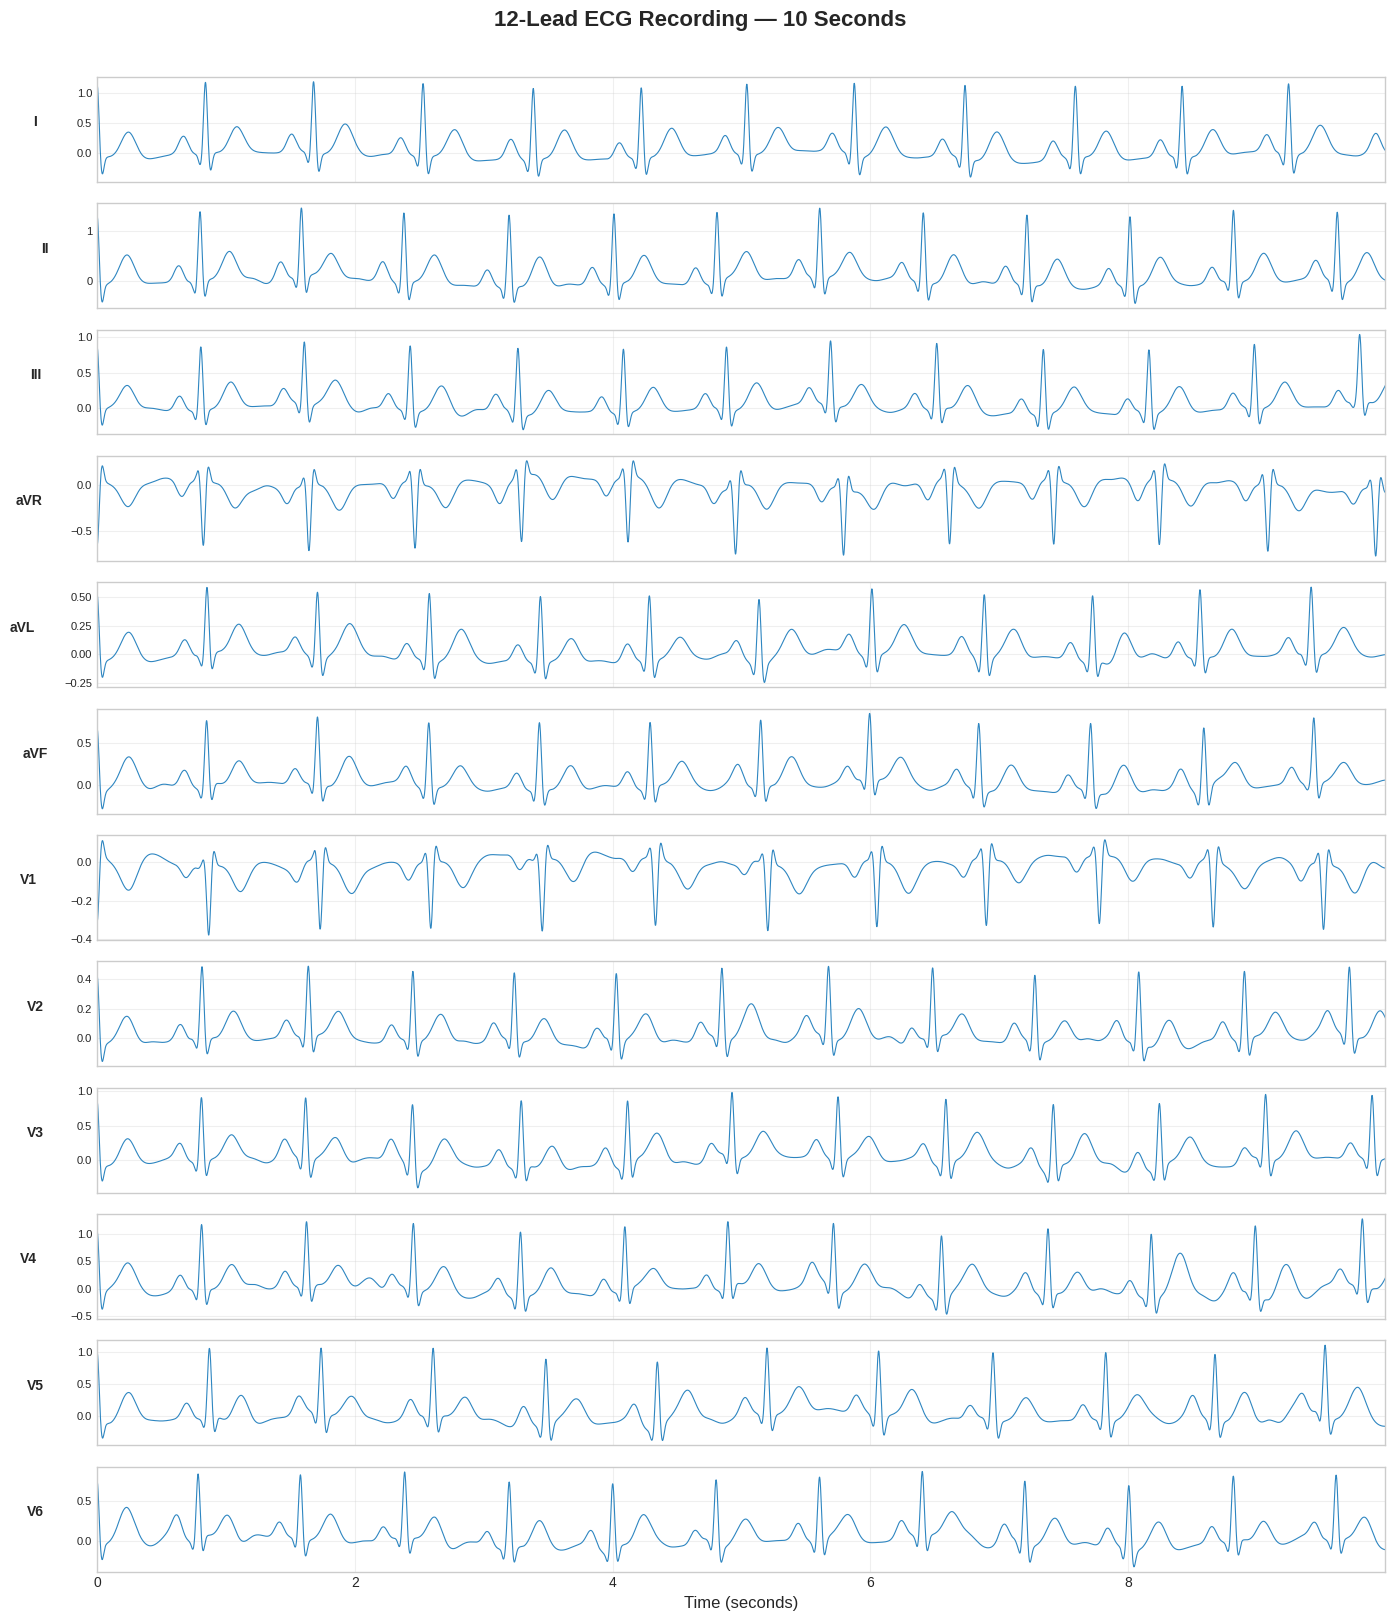

Each lead shows the heart's electrical activity from a different 'camera angle'.
A cardiologist reads all 12 leads together to localize pathology.
Data source: Synthetic (NeuroKit2)


In [4]:
# ============================================================
# Visualize: All 12 leads stacked (like a clinical ECG printout)
# ============================================================
fig, axes = plt.subplots(12, 1, figsize=(14, 16), sharex=True)
time_axis = np.arange(ecg_data.shape[0]) / sampling_rate

for i, (ax, lead) in enumerate(zip(axes, lead_names)):
    ax.plot(time_axis, ecg_data[:, i], color='#2E86C1', linewidth=0.8)
    ax.set_ylabel(lead, fontsize=10, fontweight='bold', rotation=0, labelpad=30)
    ax.set_xlim(0, time_axis[-1])
    ax.grid(True, alpha=0.3)
    # ECG paper style: minor gridlines
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_xlabel('Time (seconds)', fontsize=12)
plt.suptitle('12-Lead ECG Recording — 10 Seconds',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Each lead shows the heart's electrical activity from a different 'camera angle'.")
print("A cardiologist reads all 12 leads together to localize pathology.")
print(f"Data source: {'Synthetic (NeuroKit2)' if USE_SYNTHETIC else 'PTB-XL (PhysioNet)'}")


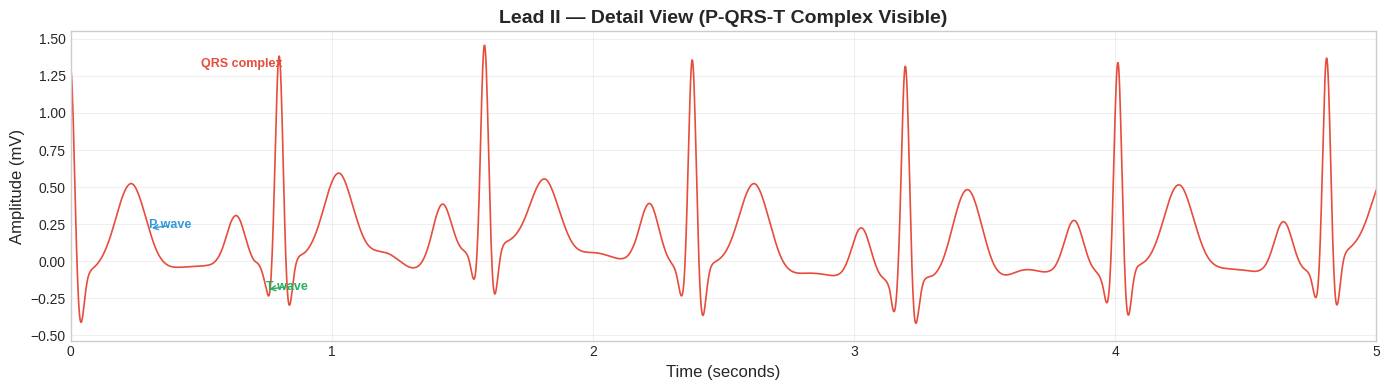

P wave = atrial depolarization, QRS = ventricular depolarization, T = repolarization.
STEMI shows ST-segment elevation between S and T — the key feature for the EMT's AI.


In [5]:
# ============================================================
# Zoom into Lead II — the most commonly analyzed lead
# ============================================================
lead_ii = ecg_data[:, 1]  # Lead II is index 1

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_axis, lead_ii, color='#E74C3C', linewidth=1.2)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude (mV)', fontsize=12)
ax.set_title('Lead II — Detail View (P-QRS-T Complex Visible)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 5)  # Show first 5 seconds for detail
ax.grid(True, alpha=0.3)

# Annotate one beat (approximate)
ax.annotate('P wave', xy=(0.3, lead_ii[150]), fontsize=9,
            color='#3498DB', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#3498DB'))
ax.annotate('QRS complex', xy=(0.5, max(lead_ii[:1000])*0.9), fontsize=9,
            color='#E74C3C', fontweight='bold')
ax.annotate('T wave', xy=(0.75, lead_ii[375]), fontsize=9,
            color='#27AE60', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27AE60'))

plt.tight_layout()
plt.show()

print("P wave = atrial depolarization, QRS = ventricular depolarization, T = repolarization.")
print("STEMI shows ST-segment elevation between S and T — the key feature for the EMT's AI.")


## 2. Preprocessing — Filter and Detect R-Peaks

Raw ECG signals contain noise from multiple sources: **baseline wander** (breathing,
electrode drift), **powerline interference** (50/60 Hz), and **muscle artifacts**
(EMG contamination). In an ambulance, all three are amplified by motion.

NeuroKit2's `ecg_clean()` applies a bandpass filter (0.5-40 Hz by default) that
removes most noise while preserving the diagnostically important P-QRS-T morphology.

After cleaning, we detect **R-peaks** — the tallest spikes marking each heartbeat.
R-peak detection is the foundation for all subsequent analysis: heart rate, HRV,
beat segmentation, and rhythm classification.

> **Corresponds to Slides S35 (Lab 1 Step 2)**


In [6]:
# ============================================================
# Section 2a: Clean the ECG signal (bandpass filter)
# ============================================================
# Use Lead II for preprocessing demonstration
raw_signal = ecg_data[:, 1].copy()

# Clean with NeuroKit2 — bandpass 0.5-40 Hz + baseline removal
cleaned_signal = nk.ecg_clean(raw_signal, sampling_rate=sampling_rate, method='neurokit')

print("Preprocessing applied:")
print("  Method: NeuroKit2 default (5th-order Butterworth bandpass 0.5-40 Hz)")
print(f"  Input length: {len(raw_signal)} samples ({len(raw_signal)/sampling_rate:.1f}s)")
print(f"  Output length: {len(cleaned_signal)} samples")
print(f"  Raw signal range:     [{raw_signal.min():.4f}, {raw_signal.max():.4f}]")
print(f"  Cleaned signal range: [{cleaned_signal.min():.4f}, {cleaned_signal.max():.4f}]")


Preprocessing applied:
  Method: NeuroKit2 default (5th-order Butterworth bandpass 0.5-40 Hz)
  Input length: 5000 samples (10.0s)
  Output length: 5000 samples
  Raw signal range:     [-0.4409, 1.4558]
  Cleaned signal range: [-1.7420, 1.1729]


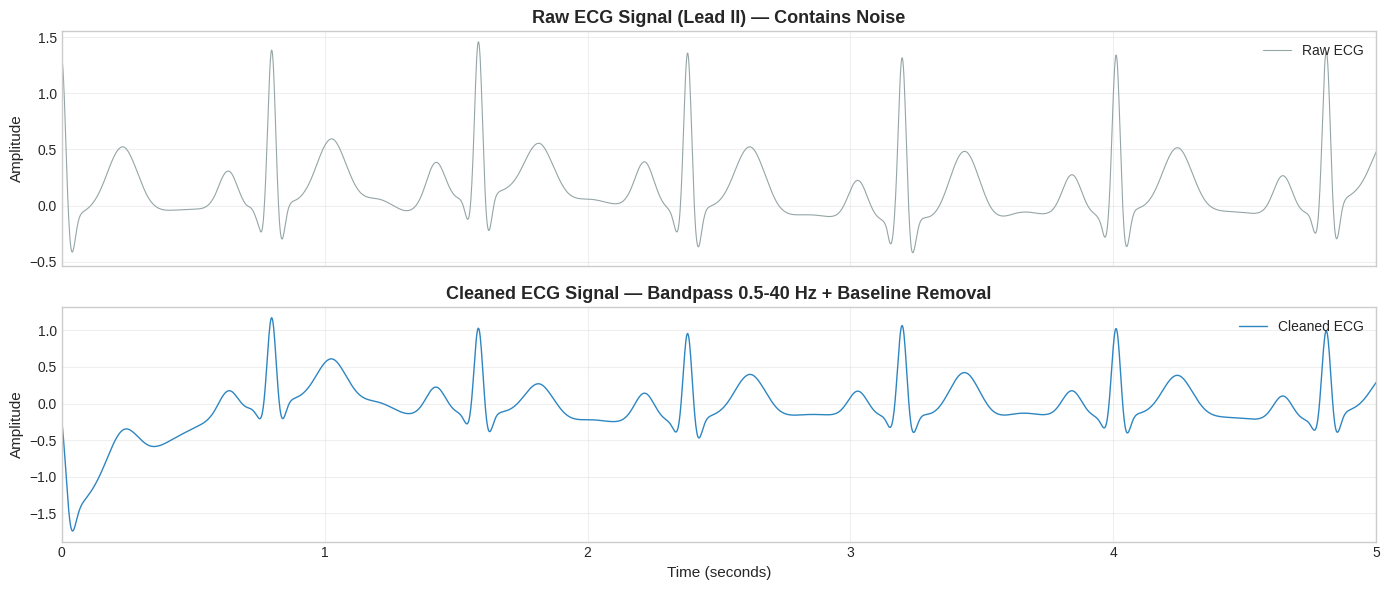

Bandpass 0.5-40 Hz removes:
  - Baseline wander (< 0.5 Hz) from breathing and electrode drift
  - Muscle noise (> 40 Hz) from EMG contamination
  - Powerline interference at 50/60 Hz
The cleaned signal preserves the diagnostically important P-QRS-T morphology.


In [7]:
# ============================================================
# Section 2b: Raw vs Filtered comparison
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Raw signal
axes[0].plot(time_axis, raw_signal, color='#95A5A6', linewidth=0.8, label='Raw ECG')
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('Raw ECG Signal (Lead II) — Contains Noise',
                   fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Cleaned signal
axes[1].plot(time_axis, cleaned_signal, color='#2E86C1', linewidth=1.0, label='Cleaned ECG')
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].set_ylabel('Amplitude', fontsize=11)
axes[1].set_title('Cleaned ECG Signal — Bandpass 0.5-40 Hz + Baseline Removal',
                   fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[0].set_xlim(0, 5)
plt.tight_layout()
plt.show()

print("Bandpass 0.5-40 Hz removes:")
print("  - Baseline wander (< 0.5 Hz) from breathing and electrode drift")
print("  - Muscle noise (> 40 Hz) from EMG contamination")
print("  - Powerline interference at 50/60 Hz")
print("The cleaned signal preserves the diagnostically important P-QRS-T morphology.")


R-peaks detected: 12 beats in 10.0 seconds
Estimated heart rate: 72.0 bpm


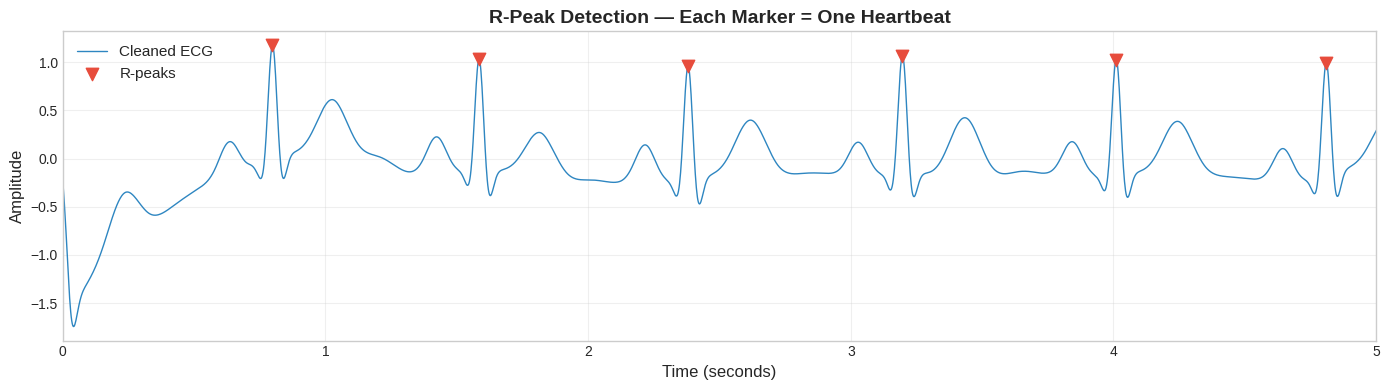


R-peak positions (first 5): [ 399  792 1190 1598 2005]
R-peak detection is the FOUNDATION for all subsequent analysis:
  -> Heart rate calculation
  -> HRV (heart rate variability) metrics
  -> Beat segmentation for classification
  -> Rhythm analysis (regular vs irregular)


In [8]:
# ============================================================
# Section 2c: R-peak detection
# ============================================================
# Detect R-peaks using NeuroKit2
_, rpeaks_info = nk.ecg_peaks(cleaned_signal, sampling_rate=sampling_rate)
r_peak_indices = rpeaks_info['ECG_R_Peaks']

print(f"R-peaks detected: {len(r_peak_indices)} beats in {len(cleaned_signal)/sampling_rate:.1f} seconds")
print(f"Estimated heart rate: {len(r_peak_indices) / (len(cleaned_signal)/sampling_rate) * 60:.1f} bpm")

# Plot cleaned ECG with R-peak markers
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_axis, cleaned_signal, color='#2E86C1', linewidth=1.0, label='Cleaned ECG')
ax.scatter(r_peak_indices / sampling_rate, cleaned_signal[r_peak_indices],
           color='#E74C3C', marker='v', s=80, zorder=5, label='R-peaks')
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('R-Peak Detection — Each Marker = One Heartbeat',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nR-peak positions (first 5): {r_peak_indices[:5]}")
print("R-peak detection is the FOUNDATION for all subsequent analysis:")
print("  -> Heart rate calculation")
print("  -> HRV (heart rate variability) metrics")
print("  -> Beat segmentation for classification")
print("  -> Rhythm analysis (regular vs irregular)")


## 3. Feature Extraction — Time-Domain (HRV Metrics)

With R-peaks detected, we compute **Heart Rate Variability (HRV)** metrics.
HRV measures the variation in time intervals between successive heartbeats.

**Clinical significance:** Low HRV predicts cardiac events — it means the heart
has lost its adaptive flexibility. HRV analysis is used for risk stratification in
post-MI patients, assessment of autonomic neuropathy in diabetes, and stress monitoring.

**Key time-domain metrics:**
- **SDNN**: Standard deviation of all RR intervals (overall variability)
- **RMSSD**: Root mean square of successive RR differences (short-term variability)
- **pNN50**: Percentage of successive RR intervals differing by >50 ms (parasympathetic marker)

> **Corresponds to Slides S36 (Lab 1 Step 3)**


In [9]:
# ============================================================
# Section 3: Compute HRV Time-Domain Features
# ============================================================
# Compute RR intervals (time between successive R-peaks, in ms)
rr_intervals = np.diff(r_peak_indices) / sampling_rate * 1000  # Convert to ms

print("=" * 60)
print("RR INTERVAL STATISTICS")
print("=" * 60)
print(f"  Number of RR intervals: {len(rr_intervals)}")
print(f"  Mean RR interval:       {np.mean(rr_intervals):.1f} ms")
print(f"  Std RR interval:        {np.std(rr_intervals):.1f} ms")
print(f"  Min RR interval:        {np.min(rr_intervals):.1f} ms")
print(f"  Max RR interval:        {np.max(rr_intervals):.1f} ms")

# Compute HRV metrics
mean_rr = np.mean(rr_intervals)
sdnn = np.std(rr_intervals, ddof=1)                    # SDNN
rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))   # RMSSD
nn50 = np.sum(np.abs(np.diff(rr_intervals)) > 50)      # NN50
pnn50 = nn50 / len(rr_intervals) * 100 if len(rr_intervals) > 0 else 0  # pNN50

# Heart rate statistics
hr_values = 60000.0 / rr_intervals  # Convert RR(ms) to HR(bpm)
mean_hr = np.mean(hr_values)

print(f"\n{'='*60}")
print("HRV TIME-DOMAIN METRICS")
print(f"{'='*60}")
print(f"  Mean Heart Rate: {mean_hr:.1f} bpm")
print(f"  SDNN:           {sdnn:.2f} ms  (overall variability)")
print(f"  RMSSD:          {rmssd:.2f} ms  (short-term / parasympathetic)")
print(f"  pNN50:          {pnn50:.1f}%     (parasympathetic marker)")
print(f"\nClinical interpretation:")
print(f"  SDNN < 50 ms = high cardiac risk in post-MI patients")
print(f"  RMSSD reflects vagal (parasympathetic) tone")
print(f"  pNN50 > 3% is generally considered normal")


RR INTERVAL STATISTICS
  Number of RR intervals: 11
  Mean RR interval:       802.4 ms
  Std RR interval:        7.9 ms
  Min RR interval:        786.0 ms
  Max RR interval:        816.0 ms

HRV TIME-DOMAIN METRICS
  Mean Heart Rate: 74.8 bpm
  SDNN:           8.24 ms  (overall variability)
  RMSSD:          8.81 ms  (short-term / parasympathetic)
  pNN50:          0.0%     (parasympathetic marker)

Clinical interpretation:
  SDNN < 50 ms = high cardiac risk in post-MI patients
  RMSSD reflects vagal (parasympathetic) tone
  pNN50 > 3% is generally considered normal


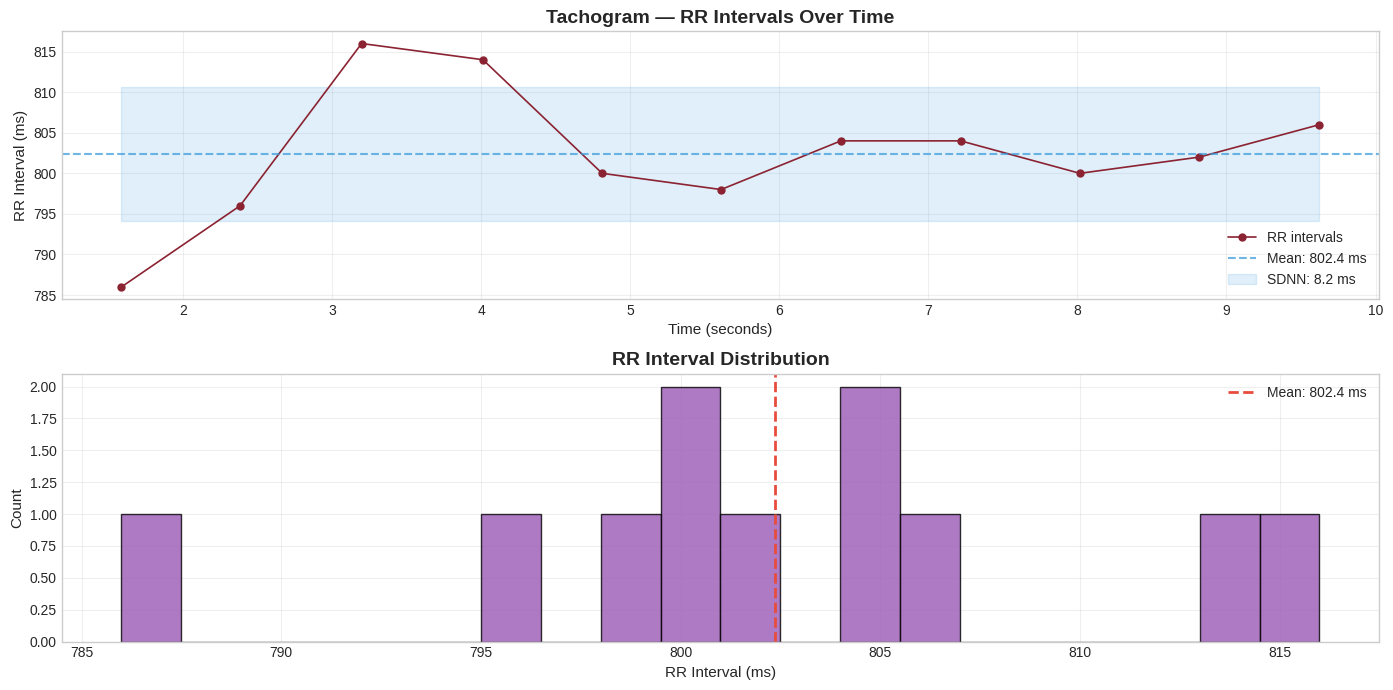

The tachogram shows beat-to-beat variability over time.
A healthy heart shows moderate variability — not too regular, not too chaotic.
Low variability (flat tachogram) = reduced autonomic control = higher cardiac risk.


In [10]:
# ============================================================
# Visualize: Tachogram (RR intervals over time)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Tachogram
beat_times = r_peak_indices[1:] / sampling_rate  # Time of each RR interval
axes[0].plot(beat_times, rr_intervals, 'o-', color='#8B2332',
             markersize=5, linewidth=1.2, label='RR intervals')
axes[0].axhline(y=mean_rr, color='#3498DB', linestyle='--', alpha=0.7,
                label=f'Mean: {mean_rr:.1f} ms')
axes[0].fill_between(beat_times, mean_rr - sdnn, mean_rr + sdnn,
                     alpha=0.15, color='#3498DB', label=f'SDNN: {sdnn:.1f} ms')
axes[0].set_xlabel('Time (seconds)', fontsize=11)
axes[0].set_ylabel('RR Interval (ms)', fontsize=11)
axes[0].set_title('Tachogram — RR Intervals Over Time',
                   fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Histogram of RR intervals
axes[1].hist(rr_intervals, bins=20, color='#9B59B6', edgecolor='black', alpha=0.8)
axes[1].axvline(x=mean_rr, color='#E74C3C', linestyle='--', linewidth=2,
                label=f'Mean: {mean_rr:.1f} ms')
axes[1].set_xlabel('RR Interval (ms)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('RR Interval Distribution',
                   fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The tachogram shows beat-to-beat variability over time.")
print("A healthy heart shows moderate variability — not too regular, not too chaotic.")
print("Low variability (flat tachogram) = reduced autonomic control = higher cardiac risk.")


## 3b. Feature Extraction — Frequency Domain (PSD, LF/HF)

The frequency domain reveals **hidden rhythms** in heart rate variability that
time-domain metrics cannot capture.

**Key frequency bands:**
- **LF (Low Frequency, 0.04-0.15 Hz)**: Reflects both sympathetic and parasympathetic activity
- **HF (High Frequency, 0.15-0.40 Hz)**: Primarily parasympathetic (vagal) activity
- **LF/HF ratio**: Approximates sympathovagal balance

**Clinical analogy:** Like decomposing an orchestra into individual instruments —
the time-domain signal is the full orchestra playing; the frequency domain separates
violin (HF/parasympathetic) from drums (LF/sympathetic).

> **Corresponds to Slides S22-S23 (Part 2: Frequency-Domain)**


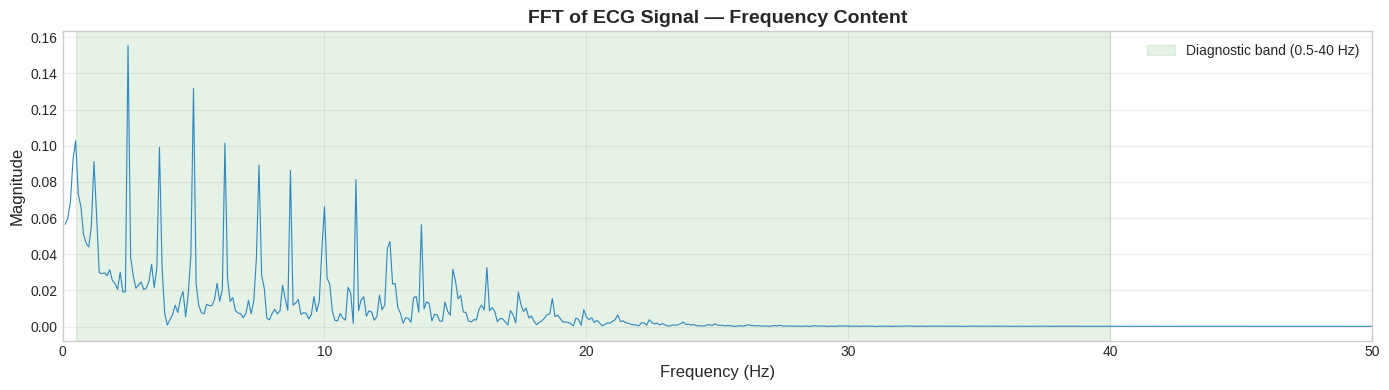

The FFT shows the frequency content of the ECG signal.
Most diagnostic information is concentrated between 0.5-40 Hz.
Frequencies above 40 Hz are mostly noise (muscle, powerline).


In [11]:
# ============================================================
# Section 3b-1: FFT of the ECG signal
# ============================================================
# Compute FFT of the cleaned ECG signal
N = len(cleaned_signal)
yf = fft(cleaned_signal)
xf = fftfreq(N, 1.0 / sampling_rate)

# Only positive frequencies
pos_mask = xf > 0
xf_pos = xf[pos_mask]
magnitude = 2.0 / N * np.abs(yf[pos_mask])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(xf_pos, magnitude, color='#2E86C1', linewidth=0.8)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)
ax.set_title('FFT of ECG Signal — Frequency Content',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 50)  # Show up to 50 Hz
ax.grid(True, alpha=0.3)

# Annotate diagnostic band
ax.axvspan(0.5, 40, alpha=0.1, color='green', label='Diagnostic band (0.5-40 Hz)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("The FFT shows the frequency content of the ECG signal.")
print("Most diagnostic information is concentrated between 0.5-40 Hz.")
print("Frequencies above 40 Hz are mostly noise (muscle, powerline).")


In [12]:
# ============================================================
# Section 3b-2: PSD of RR intervals (HRV frequency analysis)
# ============================================================
# Interpolate RR intervals to create evenly-spaced time series
# (Required for PSD computation)
rr_times = np.cumsum(rr_intervals) / 1000.0  # Convert to seconds
rr_times = rr_times - rr_times[0]  # Start from 0

# Interpolate at 4 Hz (standard for HRV frequency analysis)
interp_rate = 4.0  # Hz
interp_times = np.arange(0, rr_times[-1], 1.0 / interp_rate)
rr_interpolated = np.interp(interp_times, rr_times, rr_intervals)

# Remove mean (detrend)
rr_detrended = rr_interpolated - np.mean(rr_interpolated)

# Compute PSD using Welch's method
frequencies, psd = scipy_signal.welch(
    rr_detrended,
    fs=interp_rate,
    nperseg=min(256, len(rr_detrended)),
    noverlap=128 if len(rr_detrended) > 256 else len(rr_detrended) // 4,
    nfft=1024
)

# Calculate band powers
lf_mask = (frequencies >= 0.04) & (frequencies <= 0.15)
hf_mask = (frequencies >= 0.15) & (frequencies <= 0.40)

lf_power = np.trapz(psd[lf_mask], frequencies[lf_mask])
hf_power = np.trapz(psd[hf_mask], frequencies[hf_mask])
lf_hf_ratio = lf_power / hf_power if hf_power > 0 else float('inf')
total_power = np.trapz(psd[(frequencies >= 0.04) & (frequencies <= 0.40)],
                       frequencies[(frequencies >= 0.04) & (frequencies <= 0.40)])

print("=" * 60)
print("HRV FREQUENCY-DOMAIN METRICS")
print("=" * 60)
print(f"  LF Power (0.04-0.15 Hz): {lf_power:.4f} ms^2/Hz  (sympathetic + parasympathetic)")
print(f"  HF Power (0.15-0.40 Hz): {hf_power:.4f} ms^2/Hz  (parasympathetic)")
print(f"  LF/HF Ratio:            {lf_hf_ratio:.2f}         (sympathovagal balance)")
print(f"  Total Power:             {total_power:.4f} ms^2/Hz")


HRV FREQUENCY-DOMAIN METRICS
  LF Power (0.04-0.15 Hz): 2.8117 ms^2/Hz  (sympathetic + parasympathetic)
  HF Power (0.15-0.40 Hz): 14.7776 ms^2/Hz  (parasympathetic)
  LF/HF Ratio:            0.19         (sympathovagal balance)
  Total Power:             17.7437 ms^2/Hz


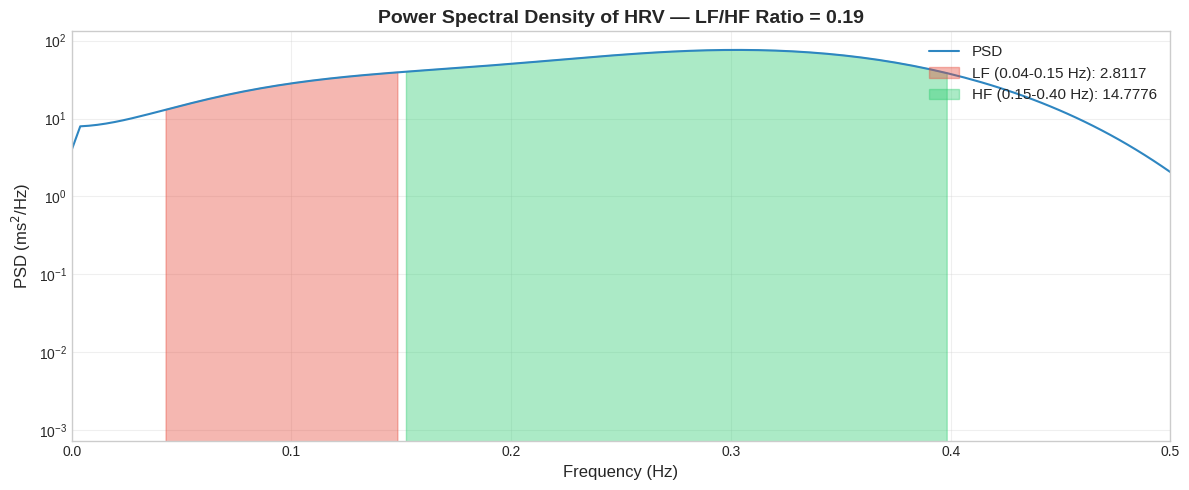

LF/HF ratio interpretation:
  Ratio > 2.0 → sympathetic dominance (stress, exercise)
  Ratio ~ 1.0 → balanced autonomic function
  Ratio < 0.5 → parasympathetic dominance (rest, athletes)

Elevated LF/HF is observed in heart failure patients — a key risk marker.


In [13]:
# ============================================================
# Section 3b-3: PSD plot with LF/HF bands highlighted
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

# Full PSD
ax.semilogy(frequencies, psd, color='#2E86C1', linewidth=1.5, label='PSD')

# Highlight LF band
ax.fill_between(frequencies[lf_mask], psd[lf_mask], alpha=0.4,
                color='#E74C3C', label=f'LF (0.04-0.15 Hz): {lf_power:.4f}')
# Highlight HF band
ax.fill_between(frequencies[hf_mask], psd[hf_mask], alpha=0.4,
                color='#2ECC71', label=f'HF (0.15-0.40 Hz): {hf_power:.4f}')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('PSD (ms$^2$/Hz)', fontsize=12)
ax.set_title(f'Power Spectral Density of HRV — LF/HF Ratio = {lf_hf_ratio:.2f}',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 0.5)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("LF/HF ratio interpretation:")
print("  Ratio > 2.0 → sympathetic dominance (stress, exercise)")
print("  Ratio ~ 1.0 → balanced autonomic function")
print("  Ratio < 0.5 → parasympathetic dominance (rest, athletes)")
print("\nElevated LF/HF is observed in heart failure patients — a key risk marker.")


## 4. Data Preparation for 1D-CNN

Now we prepare data for deep learning classification. Instead of extracting HRV features
(traditional ML approach), the **1D-CNN will learn directly from raw waveform segments**.

**Strategy:**
1. Simulate a dataset of ECG segments (normal vs abnormal)
2. Each segment = 500 samples (1 second at 500 Hz) — roughly one heartbeat
3. Normalize each segment independently
4. Reshape for Conv1D input: `(n_samples, 500, 1)`

**Clinical framing:** Each window is like one "snapshot" of the heart — the CNN
must learn to distinguish normal sinus rhythm from abnormal morphology, just like
the AI on the EMT's tablet.

> **Corresponds to Slides S55 (Lab 2 Step 4)**


In [14]:
# ============================================================
# Section 4a: Generate ECG dataset (normal + abnormal segments)
# ============================================================
# For a Colab-friendly demo, we simulate a labeled ECG dataset.
# In production, you would use PTB-XL annotations.

n_normal = 300
n_abnormal = 200
segment_length = 500  # 1 second at 500 Hz

print("Generating labeled ECG segments for classification...")
print(f"  Normal segments (class 0): {n_normal}")
print(f"  Abnormal segments (class 1): {n_abnormal}")
print(f"  Segment length: {segment_length} samples ({segment_length/sampling_rate:.1f}s)")

segments = []
labels = []

# --- Normal sinus rhythm segments ---
for i in range(n_normal):
    # Simulate normal ECG with slight natural variation
    hr = np.random.uniform(60, 90)          # Normal heart rate range
    noise_level = np.random.uniform(0.01, 0.05)
    sig = nk.ecg_simulate(duration=1.0, sampling_rate=sampling_rate,
                           heart_rate=hr, noise=noise_level,
                           random_state=i)[:segment_length]
    # Ensure correct length
    if len(sig) < segment_length:
        sig = np.pad(sig, (0, segment_length - len(sig)), mode='edge')
    segments.append(sig[:segment_length])
    labels.append(0)

# --- Abnormal segments (simulated arrhythmia patterns) ---
for i in range(n_abnormal):
    hr = np.random.uniform(40, 150)  # Abnormal heart rates (brady/tachycardia)
    noise_level = np.random.uniform(0.05, 0.15)  # Higher noise (motion artifact)

    sig = nk.ecg_simulate(duration=1.0, sampling_rate=sampling_rate,
                           heart_rate=hr, noise=noise_level,
                           random_state=1000 + i)[:segment_length]

    # Add abnormal morphology: ST elevation, extra peaks, or irregular baseline
    abnormality_type = i % 4
    if abnormality_type == 0:
        # ST elevation (STEMI-like)
        st_start = int(segment_length * 0.35)
        st_end = int(segment_length * 0.55)
        sig[st_start:st_end] += np.random.uniform(0.2, 0.5)
    elif abnormality_type == 1:
        # Premature ventricular contraction (wide QRS)
        pvc_start = int(segment_length * 0.3)
        pvc_width = int(segment_length * 0.15)
        sig[pvc_start:pvc_start+pvc_width] *= np.random.uniform(1.5, 2.5)
    elif abnormality_type == 2:
        # Atrial fibrillation (irregular baseline, absent P-waves)
        sig += 0.1 * np.random.randn(segment_length)
        sig[:int(segment_length*0.2)] *= 0.3  # Diminish P-wave
    else:
        # Bradycardia with ectopic beats
        ectopic_pos = np.random.randint(segment_length // 3, 2 * segment_length // 3)
        sig[ectopic_pos:ectopic_pos+20] += np.random.uniform(0.3, 0.6)

    if len(sig) < segment_length:
        sig = np.pad(sig, (0, segment_length - len(sig)), mode='edge')
    segments.append(sig[:segment_length])
    labels.append(1)

X_raw = np.array(segments)   # shape: (500, 500)
y_raw = np.array(labels)     # shape: (500,)

print(f"\nDataset created: X_raw shape = {X_raw.shape}, y_raw shape = {y_raw.shape}")
print(f"  Class 0 (Normal): {np.sum(y_raw == 0)}")
print(f"  Class 1 (Abnormal): {np.sum(y_raw == 1)}")


Generating labeled ECG segments for classification...
  Normal segments (class 0): 300
  Abnormal segments (class 1): 200
  Segment length: 500 samples (1.0s)

Dataset created: X_raw shape = (500, 500), y_raw shape = (500,)
  Class 0 (Normal): 300
  Class 1 (Abnormal): 200


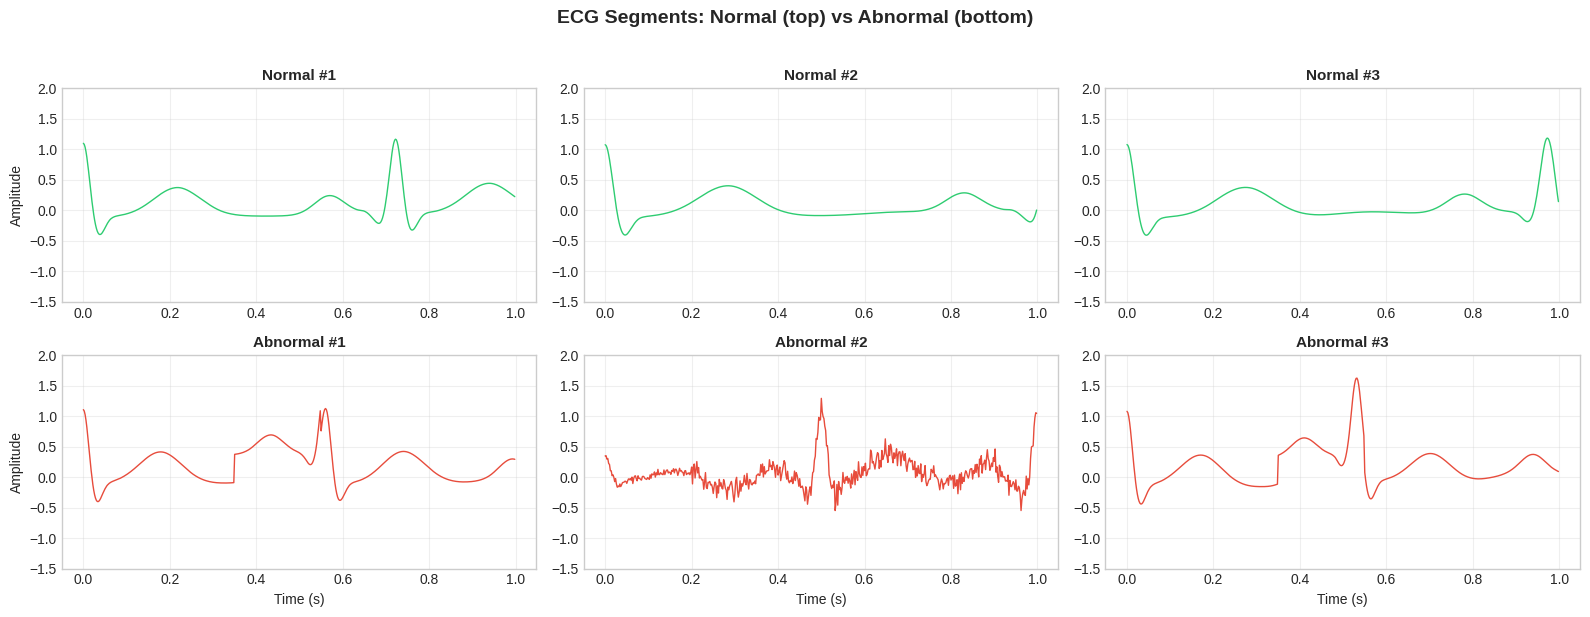

Can you see the differences? The CNN will learn to detect these patterns automatically.


In [15]:
# ============================================================
# Section 4b: Visualize example segments
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
t_seg = np.arange(segment_length) / sampling_rate

# Normal examples
for i in range(3):
    idx = np.where(y_raw == 0)[0][i * 30]
    axes[0, i].plot(t_seg, X_raw[idx], color='#2ECC71', linewidth=1.0)
    axes[0, i].set_title(f'Normal #{i+1}', fontsize=11, fontweight='bold')
    axes[0, i].set_ylim(-1.5, 2.0)
    axes[0, i].grid(True, alpha=0.3)
    if i == 0:
        axes[0, i].set_ylabel('Amplitude', fontsize=10)

# Abnormal examples
for i in range(3):
    idx = np.where(y_raw == 1)[0][i * 30]
    axes[1, i].plot(t_seg, X_raw[idx], color='#E74C3C', linewidth=1.0)
    axes[1, i].set_title(f'Abnormal #{i+1}', fontsize=11, fontweight='bold')
    axes[1, i].set_ylim(-1.5, 2.0)
    axes[1, i].set_xlabel('Time (s)', fontsize=10)
    axes[1, i].grid(True, alpha=0.3)
    if i == 0:
        axes[1, i].set_ylabel('Amplitude', fontsize=10)

plt.suptitle('ECG Segments: Normal (top) vs Abnormal (bottom)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Can you see the differences? The CNN will learn to detect these patterns automatically.")


In [16]:
# ============================================================
# Section 4c: Normalize and split
# ============================================================
# Normalize each segment independently (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)  # Fits per-feature (per time-step)

# For CNN: reshape to (n_samples, timesteps, 1 channel)
X_cnn = X_scaled.reshape(-1, segment_length, 1)

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

print("Data Preparation Complete:")
print(f"  X_train shape: {X_train.shape}  (samples, timesteps, channels)")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_train: {np.sum(y_train==0)} normal + {np.sum(y_train==1)} abnormal")
print(f"  y_test:  {np.sum(y_test==0)} normal + {np.sum(y_test==1)} abnormal")
print(f"\nInput shape for Conv1D: ({segment_length}, 1)")


Data Preparation Complete:
  X_train shape: (400, 500, 1)  (samples, timesteps, channels)
  X_test shape:  (100, 500, 1)
  y_train: 240 normal + 160 abnormal
  y_test:  60 normal + 40 abnormal

Input shape for Conv1D: (500, 1)


## 5. Build and Train 1D-CNN for ECG Classification

We build a **1D Convolutional Neural Network** that processes raw ECG segments end-to-end.
Unlike the traditional ML approach (extract HRV features -> Random Forest), the CNN
learns its own features directly from the waveform.

**Architecture rationale:**
- **Conv1D(32, kernel_size=7)**: Large kernel captures broad temporal patterns (QRS complex)
- **Conv1D(64, kernel_size=5)**: Smaller kernel refines detection of finer morphological features
- **MaxPooling1D(2)**: Reduces dimensionality while keeping the strongest features
- **Dropout(0.3)**: Prevents overfitting — like training junior doctors by randomly making the senior unavailable
- **Dense(64) -> Dense(1, sigmoid)**: Binary classification (normal vs abnormal)

**Clinical analogy:** Layer 1 learns to detect edges (P-wave onset). Layer 2 detects
complexes (full QRS). The final layers combine these into a diagnosis, just like a
cardiologist's training progression.

> **Corresponds to Slides S56-S57 (Lab 2 Steps 5-6)**


In [17]:
# ============================================================
# Section 5a: Build the 1D-CNN model
# ============================================================
def build_1d_cnn(input_shape):
    """Build a 1D-CNN for binary ECG classification."""
    model = models.Sequential([
        # First Conv block: detect broad temporal patterns (QRS morphology)
        layers.Conv1D(32, kernel_size=7, activation='relu',
                     input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),

        # Second Conv block: refine feature detection
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),

        # Downsample — keep strongest activations
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Third Conv block: higher-level pattern combinations
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Classification head
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')  # Binary output
    ])
    return model

# Build model
input_shape = (segment_length, 1)
model = build_1d_cnn(input_shape)

# Compile with binary crossentropy (standard for binary classification)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display architecture
model.summary()

print(f"\nTotal parameters: {model.count_params():,}")
print(f"Input: {input_shape} (1 second of ECG @ 500 Hz)")
print(f"Output: sigmoid probability (0 = normal, 1 = abnormal)")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 500, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 500, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,024,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,289 (4.04 MB)

 Trainable params: 1,059,841 (4.04 MB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 1,060,289
Input: (500, 1) (1 second of ECG @ 500 Hz)
Output: sigmoid probability (0 = normal, 1 = abnormal)


In [18]:
# ============================================================
# Section 5b: Train the model
# ============================================================
print("Training 1D-CNN...")
print("=" * 60)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,      # Hold out 20% of training for validation
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]
)

print(f"\nTraining complete!")
print(f"  Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Best val_loss:     {min(history.history['val_loss']):.4f}")
print(f"  Epochs trained:    {len(history.history['loss'])}")


Training 1D-CNN...
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 649ms/step - accuracy: 0.8043 - loss: 0.6684 - val_accuracy: 0.9875 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 433ms/step - accuracy: 0.9571 - loss: 0.1688 - val_accuracy: 0.9125 - val_loss: 0.2258 - learning_rate: 0.0010
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 541ms/step - accuracy: 0.9713 - loss: 0.1285 - val_accuracy: 0.8250 - val_loss: 0.4035 - learning_rate: 0.0010
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 357ms/step - accuracy: 0.9768 - loss: 0.0792 - val_accuracy: 0.7625 - val_loss: 0.7596 - learning_rate: 0.0010
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9913 - loss: 0.0331
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 339ms/step - accuracy: 0.9912 - loss: 0.0366 - val_accuracy: 0.6875 - val_loss: 1.2089 - learning_rate: 0.0010
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 453ms/step - accuracy: 0.989

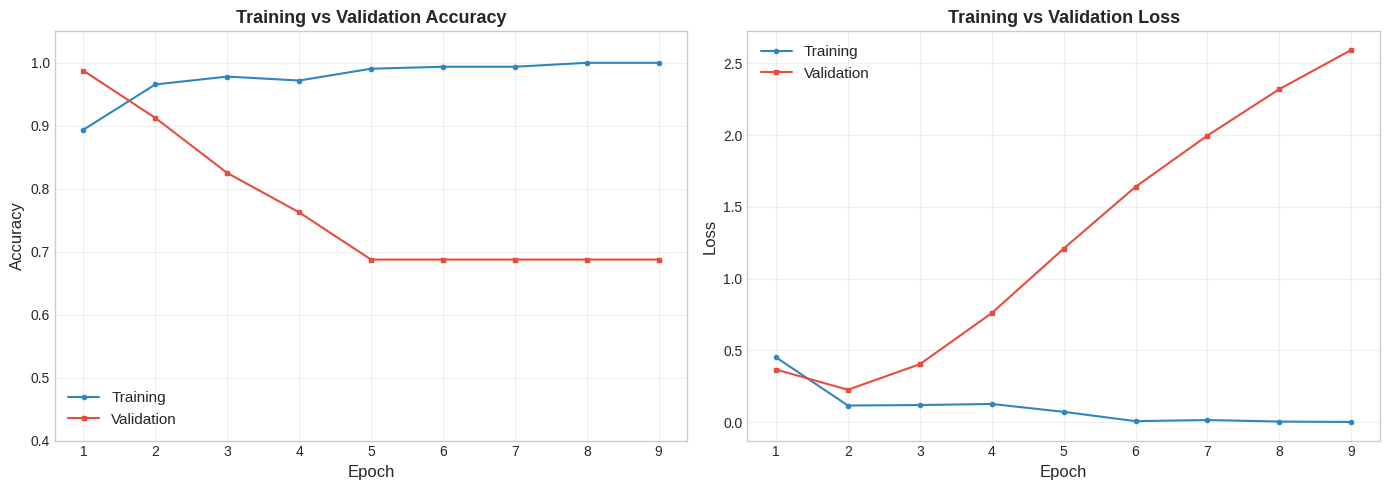

Watch for overfitting: if val_loss rises while train_loss falls,
the model is memorizing training data instead of learning general patterns.
EarlyStopping prevents this by restoring the best weights.


In [19]:
# ============================================================
# Section 5c: Plot training/validation curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

# Accuracy curves
axes[0].plot(epochs_range, history.history['accuracy'],
             'o-', color='#2E86C1', label='Training', markersize=3)
axes[0].plot(epochs_range, history.history['val_accuracy'],
             's-', color='#E74C3C', label='Validation', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training vs Validation Accuracy',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.4, 1.05)

# Loss curves
axes[1].plot(epochs_range, history.history['loss'],
             'o-', color='#2E86C1', label='Training', markersize=3)
axes[1].plot(epochs_range, history.history['val_loss'],
             's-', color='#E74C3C', label='Validation', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Training vs Validation Loss',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Watch for overfitting: if val_loss rises while train_loss falls,")
print("the model is memorizing training data instead of learning general patterns.")
print("EarlyStopping prevents this by restoring the best weights.")


## 6. Evaluation — Confusion Matrix, ROC Curve, and ML vs DL Comparison

Now we evaluate the trained 1D-CNN on the **held-out test set** (data the model
has never seen during training). We also train a **Random Forest on HRV features**
to compare the traditional ML approach against the deep learning approach.

**Clinical metrics that matter:**
- **Sensitivity (Recall)**: Of all actual STEMIs, how many did we catch? (Miss = death)
- **Specificity**: Of all normals, how many did we correctly identify? (False alarm = unnecessary cath lab activation)
- **AUC-ROC**: Overall discriminative ability across all thresholds

> **Corresponds to Slides S58-S59 (Lab 2 Steps 7-8)**


In [20]:
# ============================================================
# Section 6a: 1D-CNN predictions on test set
# ============================================================
# Predict probabilities and binary labels
y_proba_cnn = model.predict(X_test, verbose=0).flatten()
y_pred_cnn = (y_proba_cnn >= 0.5).astype(int)

# Classification report
print("=" * 60)
print("1D-CNN CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_cnn,
      target_names=['Normal (0)', 'Abnormal (1)']))

acc_cnn = accuracy_score(y_test, y_pred_cnn)
auc_cnn = roc_auc_score(y_test, y_proba_cnn)
print(f"Accuracy: {acc_cnn:.4f}")
print(f"AUC-ROC:  {auc_cnn:.4f}")


1D-CNN CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

  Normal (0)       0.86      1.00      0.92        60
Abnormal (1)       1.00      0.75      0.86        40

    accuracy                           0.90       100
   macro avg       0.93      0.88      0.89       100
weighted avg       0.91      0.90      0.90       100

Accuracy: 0.9000
AUC-ROC:  0.9875


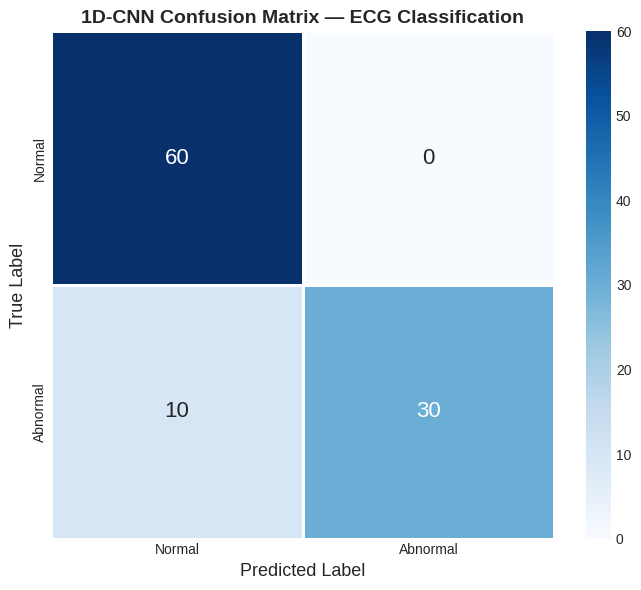


Clinical Metrics:
  Sensitivity (Recall):  0.7500 — catches 75.0% of abnormals
  Specificity:           1.0000 — correctly identifies 100.0% of normals
  PPV (Precision):       1.0000 — when it says abnormal, it's right 100.0% of the time
  NPV:                   0.8571 — when it says normal, it's right 85.7% of the time


In [21]:
# ============================================================
# Section 6b: Confusion matrix heatmap
# ============================================================
cm = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'],
            annot_kws={'size': 16}, linewidths=1, linecolor='white')
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('1D-CNN Confusion Matrix — ECG Classification',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Extract metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\nClinical Metrics:")
print(f"  Sensitivity (Recall):  {sensitivity:.4f} — catches {sensitivity*100:.1f}% of abnormals")
print(f"  Specificity:           {specificity:.4f} — correctly identifies {specificity*100:.1f}% of normals")
print(f"  PPV (Precision):       {ppv:.4f} — when it says abnormal, it's right {ppv*100:.1f}% of the time")
print(f"  NPV:                   {npv:.4f} — when it says normal, it's right {npv*100:.1f}% of the time")


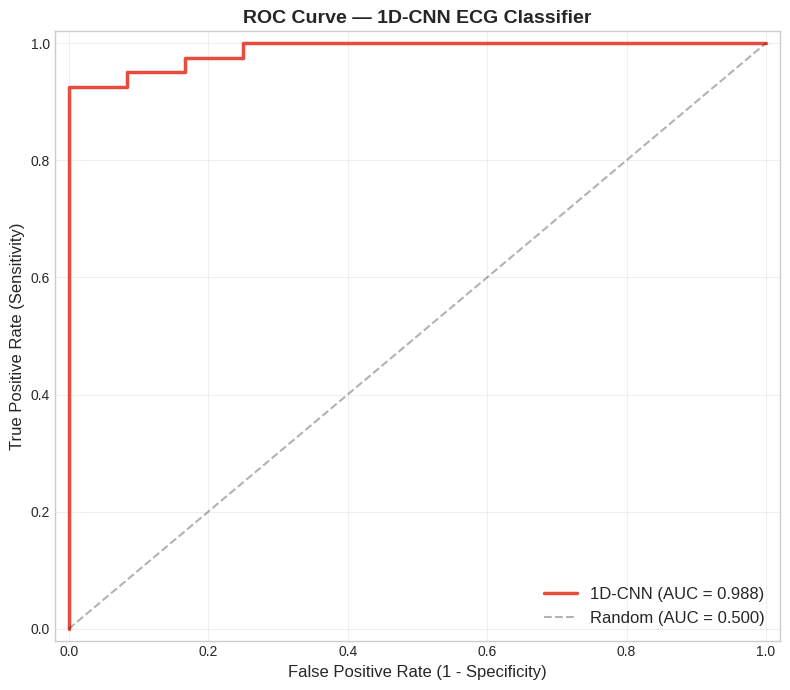

AUC = 0.988: the model's probability of ranking a random abnormal
segment higher than a random normal segment is 98.8%.


In [22]:
# ============================================================
# Section 6c: ROC Curve
# ============================================================
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(y_test, y_proba_cnn)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_cnn, tpr_cnn, color='#E74C3C', linewidth=2.5,
        label=f'1D-CNN (AUC = {auc_cnn:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve — 1D-CNN ECG Classifier',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC = {auc_cnn:.3f}: the model's probability of ranking a random abnormal")
print(f"segment higher than a random normal segment is {auc_cnn*100:.1f}%.")


In [23]:
# ============================================================
# Section 6d: Compare with Random Forest on HRV features
# ============================================================
# Traditional ML approach: extract HRV features per segment, then classify

print("Building Random Forest baseline on HRV features...")
print("=" * 60)

def extract_hrv_features(segment, sr=500):
    """Extract simple time-domain HRV features from an ECG segment."""
    try:
        cleaned = nk.ecg_clean(segment, sampling_rate=sr)
        _, peaks = nk.ecg_peaks(cleaned, sampling_rate=sr)
        r_peaks = peaks['ECG_R_Peaks']

        if len(r_peaks) < 3:
            # Not enough peaks for HRV
            return [np.mean(segment), np.std(segment), 0, 0, 0,
                    np.max(segment) - np.min(segment),
                    np.mean(np.abs(segment)),
                    float(np.argmax(np.abs(segment))) / len(segment)]

        rr = np.diff(r_peaks) / sr * 1000  # ms
        features = [
            np.mean(rr),                              # Mean RR
            np.std(rr, ddof=1) if len(rr) > 1 else 0, # SDNN
            np.sqrt(np.mean(np.diff(rr)**2)) if len(rr) > 1 else 0,  # RMSSD
            np.sum(np.abs(np.diff(rr)) > 50) / len(rr) * 100 if len(rr) > 1 else 0,  # pNN50
            60000 / np.mean(rr),                       # Mean HR
            np.max(segment) - np.min(segment),         # Peak-to-peak amplitude
            np.mean(np.abs(segment)),                  # Mean absolute value
            float(np.argmax(np.abs(segment))) / len(segment)  # Relative position of max
        ]
        return features
    except Exception:
        # Fallback: basic statistical features
        return [0, np.std(segment), 0, 0, 0,
                np.max(segment) - np.min(segment),
                np.mean(np.abs(segment)),
                float(np.argmax(np.abs(segment))) / len(segment)]

# Extract features for all segments (use raw, un-reshaped data)
X_raw_flat = X_scaled  # Already normalized in Section 4c
feature_names_hrv = ['Mean_RR', 'SDNN', 'RMSSD', 'pNN50', 'Mean_HR',
                     'Peak2Peak', 'MeanAbs', 'MaxPos']

print("Extracting HRV features from all segments...")
hrv_features = []
for i in range(len(X_raw)):
    feats = extract_hrv_features(X_raw[i], sr=sampling_rate)
    hrv_features.append(feats)
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(X_raw)} segments...")

X_hrv = np.array(hrv_features)
print(f"HRV feature matrix: {X_hrv.shape} ({len(feature_names_hrv)} features per segment)")

# Handle NaN/Inf values
X_hrv = np.nan_to_num(X_hrv, nan=0.0, posinf=0.0, neginf=0.0)

# Train/test split (same indices as CNN for fair comparison)
X_hrv_train, X_hrv_test, y_hrv_train, y_hrv_test = train_test_split(
    X_hrv, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

# Scale HRV features
scaler_hrv = StandardScaler()
X_hrv_train_s = scaler_hrv.fit_transform(X_hrv_train)
X_hrv_test_s = scaler_hrv.transform(X_hrv_test)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_hrv_train_s, y_hrv_train)

y_pred_rf = rf.predict(X_hrv_test_s)
y_proba_rf = rf.predict_proba(X_hrv_test_s)[:, 1]

acc_rf = accuracy_score(y_hrv_test, y_pred_rf)
auc_rf = roc_auc_score(y_hrv_test, y_proba_rf)

print(f"\nRandom Forest Results (HRV features):")
print(classification_report(y_hrv_test, y_pred_rf,
      target_names=['Normal (0)', 'Abnormal (1)']))
print(f"Accuracy: {acc_rf:.4f}")
print(f"AUC-ROC:  {auc_rf:.4f}")


Building Random Forest baseline on HRV features...
Extracting HRV features from all segments...
  Processed 100/500 segments...
  Processed 200/500 segments...
  Processed 300/500 segments...
  Processed 400/500 segments...
  Processed 500/500 segments...
HRV feature matrix: (500, 8) (8 features per segment)

Random Forest Results (HRV features):
              precision    recall  f1-score   support

  Normal (0)       0.97      0.98      0.98        60
Abnormal (1)       0.97      0.95      0.96        40

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

Accuracy: 0.9700
AUC-ROC:  0.9860


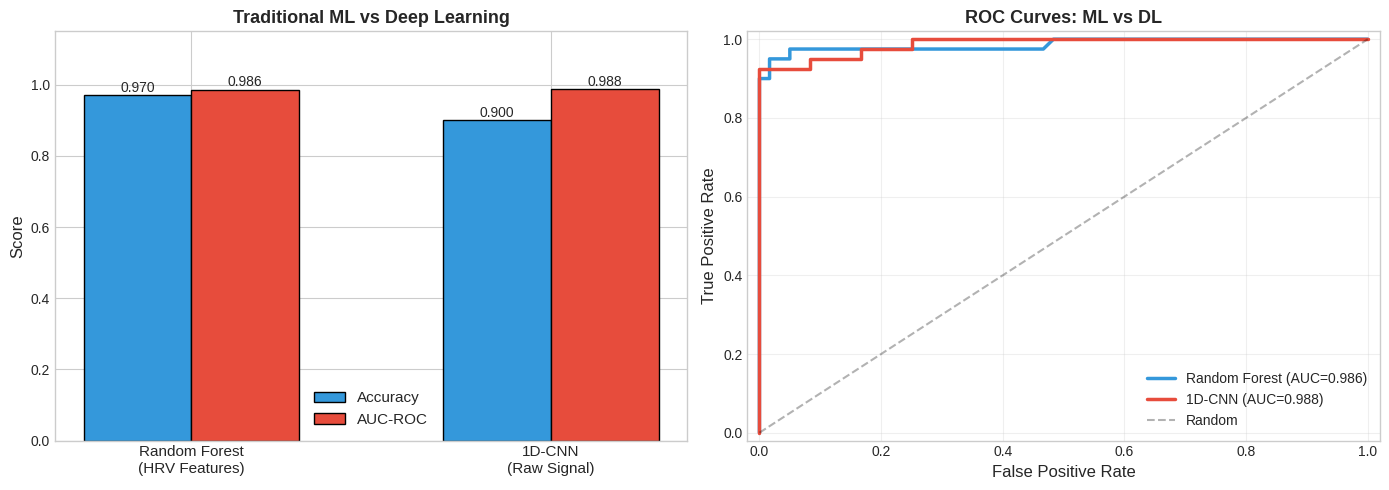


COMPARISON SUMMARY: Feature-Based ML vs End-to-End DL
  Approach                         Accuracy        AUC
  ----------------------------------------------------
  Random Forest (HRV features)       0.9700     0.9860
  1D-CNN (raw signal)                0.9000     0.9875

Key insight:
  RF uses 8 hand-crafted HRV features (100 years of cardiology knowledge)
  CNN uses 500 raw data points and learns its own features
  On real datasets (PTB-XL, MIT-BIH), CNNs typically outperform RF by 3-8%
  Trade-off: CNN needs more data + compute, RF is more interpretable


In [24]:
# ============================================================
# Section 6e: Head-to-head comparison — ML vs DL
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
models_names = ['Random Forest\n(HRV Features)', '1D-CNN\n(Raw Signal)']
accuracies = [acc_rf, acc_cnn]
aucs = [auc_rf, auc_cnn]

x = np.arange(len(models_names))
width = 0.3

bars1 = axes[0].bar(x - width/2, accuracies, width, label='Accuracy',
                     color='#3498DB', edgecolor='black')
bars2 = axes[0].bar(x + width/2, aucs, width, label='AUC-ROC',
                     color='#E74C3C', edgecolor='black')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Traditional ML vs Deep Learning',
                   fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names, fontsize=11)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 1.15)
for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=10)

# ROC curves overlay
fpr_rf, tpr_rf, _ = roc_curve(y_hrv_test, y_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, color='#3498DB', linewidth=2.5,
             label=f'Random Forest (AUC={auc_rf:.3f})')
axes[1].plot(fpr_cnn, tpr_cnn, color='#E74C3C', linewidth=2.5,
             label=f'1D-CNN (AUC={auc_cnn:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves: ML vs DL',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='lower right')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("COMPARISON SUMMARY: Feature-Based ML vs End-to-End DL")
print("=" * 60)
print(f"  {'Approach':<30} {'Accuracy':>10} {'AUC':>10}")
print(f"  {'-'*52}")
print(f"  {'Random Forest (HRV features)':<30} {acc_rf:>10.4f} {auc_rf:>10.4f}")
print(f"  {'1D-CNN (raw signal)':<30} {acc_cnn:>10.4f} {auc_cnn:>10.4f}")
print(f"\nKey insight:")
print(f"  RF uses 8 hand-crafted HRV features (100 years of cardiology knowledge)")
print(f"  CNN uses {segment_length} raw data points and learns its own features")
print(f"  On real datasets (PTB-XL, MIT-BIH), CNNs typically outperform RF by 3-8%")
print(f"  Trade-off: CNN needs more data + compute, RF is more interpretable")


## 7. Student Tasks

Complete the following tasks to deepen your understanding of biomedical signal
processing and deep learning for ECG classification.

| Task | Description | Difficulty |
|------|-------------|------------|
| T1 | Add BatchNormalization after each Conv1D layer | :star: |
| T2 | Implement Grad-CAM saliency for 1D-CNN | :star: |
| T3 | Add LSTM layer after Conv1D (CNN-LSTM hybrid) | :star::star: |
| T4 | Apply signal augmentation (jittering + Gaussian noise) | :star::star: |
| T5 | Multi-class classification (5 rhythm types) | :star::star::star: |

> **Corresponds to Slides S60 (Lab 2 Exercise Tasks)**


In [25]:
# ============================================================
# Task 1 (Star): Add BatchNormalization after each Conv1D
# ============================================================
# The model we trained already includes BatchNormalization.
# Your task: REMOVE all BatchNorm layers and retrain.
# Then compare accuracy WITH vs WITHOUT BatchNorm.
#
# Hint: Create a new model without BatchNormalization:

def build_cnn_no_batchnorm(input_shape):
    model = models.Sequential([
        layers.Conv1D(32, kernel_size=7, activation='relu',
                     input_shape=input_shape, padding='same'),
        # NO BatchNormalization here
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        # NO BatchNormalization here
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        # NO BatchNormalization here
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# TODO: Build, compile, train, and compare results
# model_no_bn = build_cnn_no_batchnorm((segment_length, 1))
# model_no_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# history_no_bn = model_no_bn.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32)
# Compare: history.history['val_accuracy'] vs history_no_bn.history['val_accuracy']

# YOUR CODE HERE:



In [26]:
# ============================================================
# Task 2 (Star): Grad-CAM Saliency for 1D-CNN
# ============================================================
# Grad-CAM shows WHICH PART of the ECG the model focuses on.
# This is critical for clinical trust — the doctor needs to see
# that the model is looking at the right waveform features.
#
# Starter code for 1D Grad-CAM:

def grad_cam_1d(model, input_signal, last_conv_layer_name):
    """Compute Grad-CAM saliency map for a 1D-CNN."""
    # Create a model that outputs both the conv layer output and the prediction
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(input_signal)
        # For binary: use the single output directly
        target_output = predictions[:, 0]

    # Gradient of the output w.r.t. the conv layer output
    grads = tape.gradient(target_output, conv_output)

    # Global average pooling of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=1, keepdims=True)

    # Weight the conv output by the pooled gradients
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap)  # Only positive contributions
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)  # Normalize

    return heatmap.numpy().flatten()

# TODO: Apply Grad-CAM to a test sample and visualize
# Find the name of the last Conv1D layer:
# for layer in model.layers:
#     if 'conv1d' in layer.name:
#         last_conv_name = layer.name
# print(f"Last Conv1D layer: {last_conv_name}")
#
# sample = X_test[0:1]
# heatmap = grad_cam_1d(model, sample, last_conv_name)
# Resize heatmap to match input length and overlay on ECG signal

# YOUR CODE HERE:



In [27]:
# ============================================================
# Task 3 (Star-Star): CNN-LSTM Hybrid Architecture
# ============================================================
# The dominant architecture for ECG classification combines:
# CNN (morphological features) + LSTM (temporal dependencies)
#
# Hint:
# def build_cnn_lstm(input_shape):
#     model = models.Sequential([
#         layers.Conv1D(32, 7, activation='relu', input_shape=input_shape, padding='same'),
#         layers.BatchNormalization(),
#         layers.Conv1D(64, 5, activation='relu', padding='same'),
#         layers.BatchNormalization(),
#         layers.MaxPooling1D(2),
#         layers.Dropout(0.3),
#         # ADD LSTM layer here — processes the CNN features as a sequence
#         layers.LSTM(64, return_sequences=False),
#         layers.Dropout(0.3),
#         layers.Dense(32, activation='relu'),
#         layers.Dense(1, activation='sigmoid')
#     ])
#     return model
#
# model_hybrid = build_cnn_lstm((segment_length, 1))
# model_hybrid.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# history_hybrid = model_hybrid.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32)
# Compare AUC: pure CNN vs CNN-LSTM

# YOUR CODE HERE:



In [28]:
# ============================================================
# Task 4 (Star-Star): Signal Augmentation
# ============================================================
# ECG-specific augmentation techniques:
# 1. Jittering: add small random noise to each time step
# 2. Gaussian noise: add N(0, sigma) noise to the entire signal
# 3. Scaling: randomly scale amplitude by a factor
#
# Hint:
# def augment_ecg(signal, jitter_sigma=0.03, noise_sigma=0.05, scale_range=(0.8, 1.2)):
#     augmented = signal.copy()
#     # Jittering
#     augmented += np.random.normal(0, jitter_sigma, size=signal.shape)
#     # Gaussian noise
#     augmented += np.random.normal(0, noise_sigma, size=signal.shape)
#     # Random scaling
#     scale = np.random.uniform(scale_range[0], scale_range[1])
#     augmented *= scale
#     return augmented
#
# # Augment only the training set
# X_train_aug = np.concatenate([X_train] + [
#     np.array([augment_ecg(x) for x in X_train]) for _ in range(2)
# ], axis=0)
# y_train_aug = np.concatenate([y_train] * 3, axis=0)
#
# print(f"Original training set: {X_train.shape[0]} samples")
# print(f"Augmented training set: {X_train_aug.shape[0]} samples")
# Retrain and compare performance.

# YOUR CODE HERE:



In [29]:
# ============================================================
# Task 5 (Star-Star-Star): Multi-class Classification
# ============================================================
# Extend from binary (normal/abnormal) to 5 rhythm types:
# 0: Normal Sinus Rhythm
# 1: Atrial Fibrillation (AF)
# 2: STEMI (ST Elevation)
# 3: Left Bundle Branch Block (LBBB)
# 4: Right Bundle Branch Block (RBBB)
#
# Hints:
# 1. Generate 5 different synthetic signal patterns (modify Section 4)
# 2. Change output layer: Dense(5, activation='softmax')
# 3. Change loss: 'sparse_categorical_crossentropy'
# 4. Use confusion matrix with 5 classes
# 5. Evaluate per-class sensitivity — STEMI sensitivity is the most critical
#
# Key changes to the model:
# model = models.Sequential([
#     ...  # Same Conv layers
#     layers.Dense(5, activation='softmax')  # 5-class output
# ])
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])
#
# Expected challenge: class imbalance — use class_weight parameter in model.fit()

# YOUR CODE HERE:



## 8. Gemini AI Exercise

Use Google Colab's built-in **Gemini AI** to deepen your understanding of
biomedical signal processing, 1D-CNN architectures, and clinical deployment.

These three prompts explore: (1) architecture intuition, (2) data augmentation
strategies, and (3) feature domain comparison.

> **Corresponds to Slides S61 (Lab 2 Clinical Reality Check + Gemini)**


In [30]:
# ============================================================
# Section 8a: Gemini Prompt 1 — Explain 1D-CNN for ECG
# ============================================================
try:
    from google.colab import ai

    print("Gemini Prompt 1: How does a 1D-CNN process an ECG signal?")
    print("=" * 60)
    response = ai.generate_text(
        "Explain how a 1D convolutional neural network processes an ECG signal. "
        "What does each layer learn? Use a medical analogy. "
        "Specifically, explain what a kernel_size=7 Conv1D layer detects "
        "vs a kernel_size=3 layer in terms of ECG waveform features."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("This section works only in Google Colab.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print("-" * 60)
    print('"Explain how a 1D convolutional neural network processes an ECG signal.')
    print('What does each layer learn? Use a medical analogy.')
    print('Specifically, explain what a kernel_size=7 Conv1D layer detects')
    print('vs a kernel_size=3 layer in terms of ECG waveform features."')


Gemini Prompt 1: How does a 1D-CNN process an ECG signal?
Imagine an Electrocardiogram (ECG) signal as a patient's heart "speaking" in a continuous electrical language. A 1D Convolutional Neural Network (CNN) acts like a highly specialized team of cardiologists and medical assistants, each with different expertise, working together to understand this language and diagnose conditions.

---

### The Medical Analogy: A Team of Heart Specialists

Let's represent the 1D CNN as a "Cardiac Diagnostic Team":

*   **Input Layer:** The raw ECG signal from the patient – a continuous stream of electrical voltage measurements over time. This is like the **patient themselves**, providing their heart's electrical activity.

*   **Convolutional Layers:** These are the **specialized medical staff** – interns, residents, and attending cardiologists – each focusing on different aspects of the ECG strip. They use "filters" (their medical knowledge and observational skills) to scan the ECG for specific pat

In [31]:
# ============================================================
# Section 8b: Gemini Prompt 2 — ECG Augmentation Strategies
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 2: ECG data augmentation strategies")
    print("=" * 60)
    response = ai.generate_text(
        "I have a 1D-CNN for ECG classification achieving 92% accuracy but only "
        "78% sensitivity for STEMI. Suggest 3 data augmentation strategies "
        "specific to ECG signals and explain why each helps. Include: "
        "(1) a time-domain technique, (2) a frequency-domain technique, and "
        "(3) a generative approach (e.g., GAN-based). Provide Python code snippets."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print("-" * 60)
    print('"I have a 1D-CNN for ECG classification achieving 92% accuracy but only')
    print('78% sensitivity for STEMI. Suggest 3 data augmentation strategies')
    print('specific to ECG signals and explain why each helps."')



Gemini Prompt 2: ECG data augmentation strategies
Improving sensitivity for STEMI (ST-segment Elevation Myocardial Infarction) is crucial, as false negatives can have severe consequences. Data augmentation can help by increasing the diversity of the STEMI samples, making your 1D-CNN more robust and better able to identify varied presentations of the condition.

Here are three data augmentation strategies specific to ECG signals, with explanations and Python code snippets:

---

### 1. Time-Domain Technique: Magnitude Scaling (Amplitude Scaling)

**Description:** This technique involves randomly scaling the amplitude of the entire ECG signal by a certain factor. The scaling factor is usually chosen from a predefined range (e.g., 80% to 120% of the original amplitude).

**Why it helps for STEMI sensitivity:**
*   **Robustness to Signal Strength Variations:** ECG signal amplitudes can vary significantly between patients or even within the same patient due to factors like electrode placem

In [32]:
# ============================================================
# Section 8c: Gemini Prompt 3 — Feature Domain Comparison
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 3: Time vs Frequency vs DL for ECG")
    print("=" * 60)
    response = ai.generate_text(
        "Compare time-domain features (HRV) vs frequency-domain features (PSD) "
        "vs end-to-end deep learning for ECG classification. When would you "
        "choose each approach in a clinical setting? Consider: dataset size, "
        "interpretability requirements, computational resources, and "
        "regulatory approval (FDA 510(k) pathway). Provide a decision tree."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print("-" * 60)
    print('"Compare time-domain features (HRV) vs frequency-domain features (PSD)')
    print('vs end-to-end deep learning for ECG classification. When would you')
    print('choose each approach in a clinical setting? Consider dataset size,')
    print('interpretability, compute, and regulatory approval."')



Gemini Prompt 3: Time vs Frequency vs DL for ECG
In clinical ECG classification, the choice between time-domain (HRV), frequency-domain (PSD), and end-to-end deep learning approaches is multifaceted, depending heavily on the specific application, available resources, and regulatory landscape.

## Comparison of Approaches for ECG Classification

Here's a detailed comparison across the key criteria:

| Feature / Approach | Dataset Size | Interpretability Requirements | Computational Resources | Regulatory Approval (FDA 510(k)) |
| :----------------- | :----------- | :-------------------------- | :---------------------- | :-------------------------------- |
| **Time-Domain (HRV)** | Small to Medium | High (Direct physiological meaning) | Low (CPU-based calculations) | Easier (Well-established, numerous predicate devices) |
| **Frequency-Domain (PSD)** | Small to Medium | Moderate to High (Physiological meaning, but nuances in interpretation) | Low to Moderate (FFT calculation) | Easier (

## 9. Bonus: Wavelet Scalogram

The **Continuous Wavelet Transform (CWT)** decomposes the signal into a
time-frequency representation called a **scalogram**. Unlike the FFT (which
gives frequency content but loses time information), the CWT preserves BOTH
time and frequency — showing when each frequency component occurs.

**Clinical use:** Wavelet features achieved 99.92% accuracy with SVM on MIT-BIH
arrhythmias. The scalogram can also be fed as a 2D image to a CNN (image classifier),
converting the 1D signal classification problem into a 2D image classification problem.

> **Corresponds to Slides S25 (Part 2: Wavelet Scalogram)**


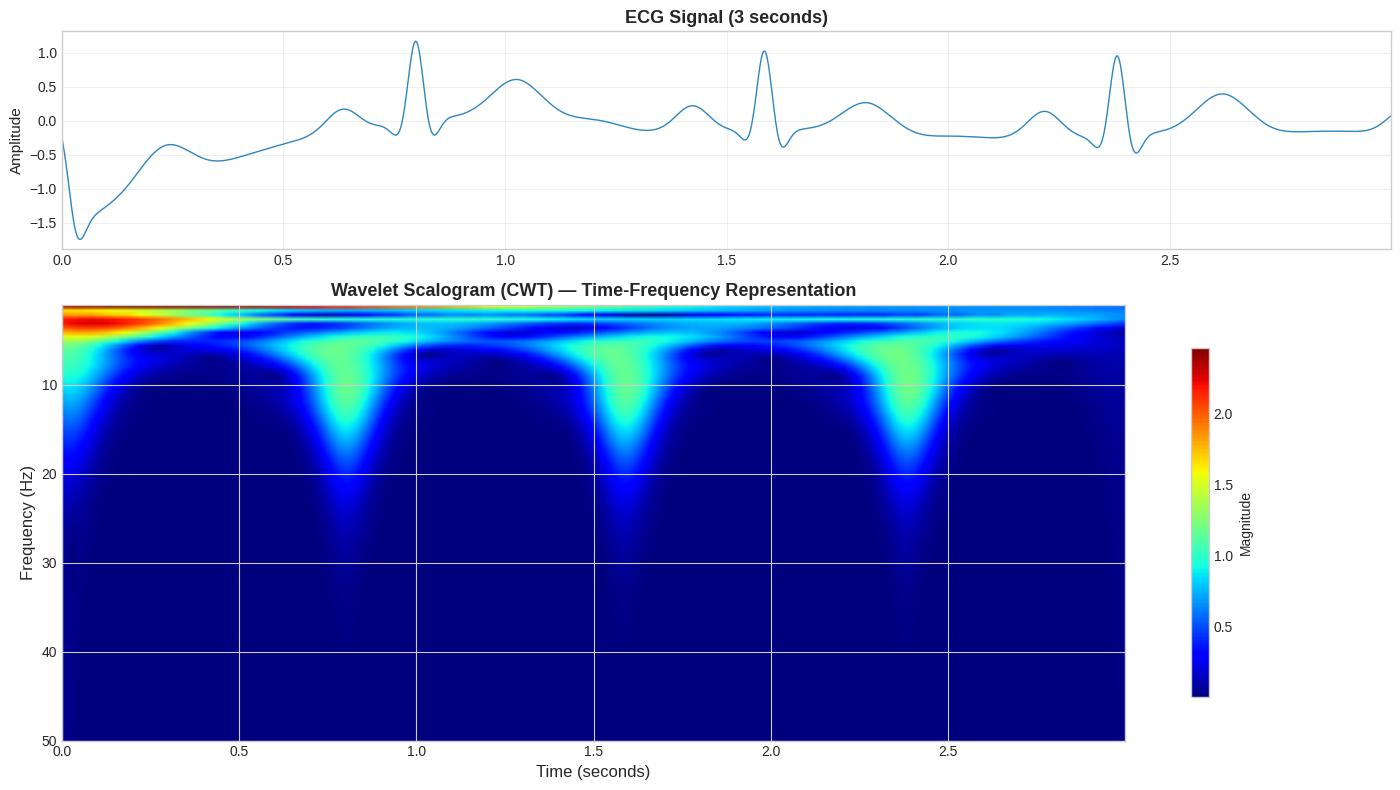

The scalogram shows WHEN and at WHAT FREQUENCY the signal has energy.
Each QRS complex appears as a bright vertical band (broad frequency content).
P and T waves appear at lower frequencies.

This 2D representation can be fed to a 2D-CNN (like an image),
converting ECG classification into an image classification problem.
Wavelet + SVM achieved 99.92% on MIT-BIH arrhythmia dataset.


In [39]:
# ============================================================
# Section 9: Continuous Wavelet Transform and Scalogram
# ============================================================
import pywt

# Use a 3-second segment of cleaned ECG for visualization
ecg_segment = cleaned_signal[:1500]  # 3 seconds at 500 Hz
t_cwt = np.arange(len(ecg_segment)) / sampling_rate

# Define frequencies of interest (1–50 Hz)
frequencies_cwt = np.linspace(1, 50, 100)
scales = pywt.frequency2scale('cmor1.5-1.0', frequencies_cwt / sampling_rate)

# Compute CWT using PyWavelets (complex Morlet wavelet)
cwt_matrix, freqs = pywt.cwt(ecg_segment, scales, 'cmor1.5-1.0', sampling_period=1/sampling_rate)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[1, 2])

# ECG signal on top
axes[0].plot(t_cwt, ecg_segment, color='#2E86C1', linewidth=1.0)
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('ECG Signal (3 seconds)', fontsize=13, fontweight='bold')
axes[0].set_xlim(t_cwt[0], t_cwt[-1])
axes[0].grid(True, alpha=0.3)

# Scalogram below
im = axes[1].imshow(
    np.abs(cwt_matrix),
    aspect='auto',
    extent=[t_cwt[0], t_cwt[-1], freqs[-1], freqs[0]],
    cmap='jet',
    interpolation='bilinear'
)
axes[1].set_xlabel('Time (seconds)', fontsize=12)
axes[1].set_ylabel('Frequency (Hz)', fontsize=12)
axes[1].set_title('Wavelet Scalogram (CWT) — Time-Frequency Representation',
                   fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Magnitude', shrink=0.8)

plt.tight_layout()
plt.show()

print("The scalogram shows WHEN and at WHAT FREQUENCY the signal has energy.")
print("Each QRS complex appears as a bright vertical band (broad frequency content).")
print("P and T waves appear at lower frequencies.")
print("\nThis 2D representation can be fed to a 2D-CNN (like an image),")
print("converting ECG classification into an image classification problem.")
print("Wavelet + SVM achieved 99.92% on MIT-BIH arrhythmia dataset.")


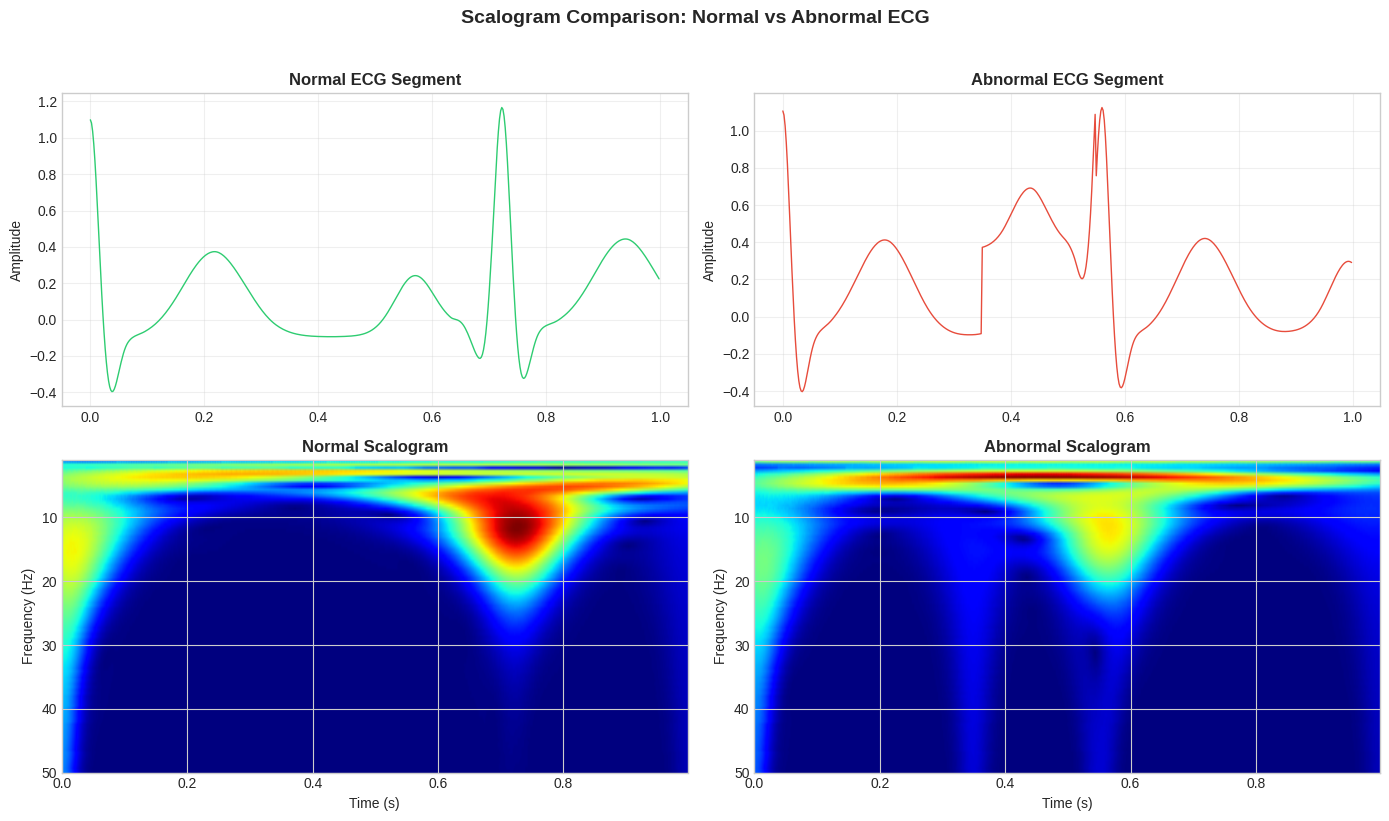

Notice the visual differences in the scalograms:
  Normal: regular, periodic QRS bands at consistent intervals
  Abnormal: irregular patterns, different frequency distribution
A 2D-CNN could classify these scalogram images with high accuracy.


In [41]:
# ============================================================
# Section 9b: Compare normal vs abnormal scalograms
# ============================================================
import pywt

t_s = np.arange(segment_length) / sampling_rate
frequencies_cwt = np.linspace(1, 50, 100)
scales = pywt.frequency2scale('cmor1.5-1.0', frequencies_cwt / sampling_rate)

# Normal segment
normal_seg = X_raw[0]
cwt_normal, freqs = pywt.cwt(normal_seg, scales, 'cmor1.5-1.0', sampling_period=1/sampling_rate)

# Abnormal segment
abnormal_idx = np.where(y_raw == 1)[0][0]
abnormal_seg = X_raw[abnormal_idx]
cwt_abnormal, _ = pywt.cwt(abnormal_seg, scales, 'cmor1.5-1.0', sampling_period=1/sampling_rate)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t_s, normal_seg, color='#2ECC71', linewidth=1.0)
axes[0, 0].set_title('Normal ECG Segment', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Amplitude', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].imshow(np.abs(cwt_normal), aspect='auto',
                   extent=[0, t_s[-1], freqs[-1], freqs[0]],
                   cmap='jet', interpolation='bilinear')
axes[1, 0].set_xlabel('Time (s)', fontsize=10)
axes[1, 0].set_ylabel('Frequency (Hz)', fontsize=10)
axes[1, 0].set_title('Normal Scalogram', fontsize=12, fontweight='bold')

axes[0, 1].plot(t_s, abnormal_seg, color='#E74C3C', linewidth=1.0)
axes[0, 1].set_title('Abnormal ECG Segment', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Amplitude', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

im2 = axes[1, 1].imshow(np.abs(cwt_abnormal), aspect='auto',
                          extent=[0, t_s[-1], freqs[-1], freqs[0]],
                          cmap='jet', interpolation='bilinear')
axes[1, 1].set_xlabel('Time (s)', fontsize=10)
axes[1, 1].set_ylabel('Frequency (Hz)', fontsize=10)
axes[1, 1].set_title('Abnormal Scalogram', fontsize=12, fontweight='bold')

plt.suptitle('Scalogram Comparison: Normal vs Abnormal ECG',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Notice the visual differences in the scalograms:")
print("  Normal: regular, periodic QRS bands at consistent intervals")
print("  Abnormal: irregular patterns, different frequency distribution")
print("A 2D-CNN could classify these scalogram images with high accuracy.")


## 10. Summary & Self-Check

### Key Takeaways (Matching Slide S75)

1. **Biomedical signals (ECG, EEG, PSG) are temporal, ordered, morphological** — not spreadsheets. Signal processing requires domain-specific techniques: filtering, peak detection, and time-frequency analysis.

2. **Preprocessing pipeline: bandpass (0.5-40 Hz) + notch (60 Hz) + baseline removal + normalization** — transforms noisy ambulance ECG into clean diagnostic signal. NeuroKit2 does this in 3 lines of code.

3. **Three feature domains: time (HRV/SDNN/RMSSD), frequency (PSD/LF/HF ratio), time-frequency (wavelet scalogram)** — each reveals different aspects of the signal. No single domain captures everything.

4. **1D-CNN and CNN-LSTM hybrid architectures achieve cardiologist-level performance** — Conv1D slides a filter over time, detecting morphological patterns (QRS shape, ST segment). LSTM adds temporal memory.

5. **Transfer learning (pre-train on 2M ECGs) + data augmentation (jittering, noise, warping)** — address the critical challenges of limited labeled data and class imbalance in clinical datasets.

6. **Edge AI deployment requires model compression** — quantization (32-bit to 8-bit = 4x smaller) and pruning enable real-time inference on ambulance tablets and wearable devices.

### Key Numbers (Matching Slide S76)

| Number | Significance |
|--------|-------------|
| 21,799 | PTB-XL ECG recordings — largest public clinical ECG database |
| 99.52% | CNN-BiLSTM accuracy on MIT-BIH arrhythmia dataset |
| 12 | Rhythm classes diagnosed by Hannun et al. (Nature Medicine 2019) |
| 4x | Model compression via INT8 quantization (32-bit to 8-bit) |
| 0.5-40 Hz | Standard ECG bandpass filter range |
| 10% | Labels needed with self-supervised learning (TSSL method) |

### Self-Check Checklist

- [ ] I can load and visualize a 12-lead ECG recording
- [ ] I understand why bandpass filtering (0.5-40 Hz) preserves diagnostic info
- [ ] I can detect R-peaks and compute HRV metrics (SDNN, RMSSD, pNN50)
- [ ] I can compute PSD and interpret LF/HF ratio in clinical context
- [ ] I built and trained a 1D-CNN for binary ECG classification
- [ ] I can evaluate with confusion matrix, ROC curve, and AUC
- [ ] I compared traditional ML (feature-based) vs deep learning (end-to-end)
- [ ] I understand why the EMT's AI needs edge deployment (speed, privacy, robustness)

### Next Week Preview

**Week 6: Regression and Time Series Forecasting**
- This week: CLASSIFICATION (normal vs abnormal signal)
- Next week: REGRESSION (predict continuous values from time series)
- Clinical scenario: ICU nurses record vitals hourly. Deterioration happens between readings. Can AI predict blood pressure trends 6 hours ahead from continuous monitoring?
- The LSTM architecture from this week becomes even more important for forecasting
- Prepare: review HRV features (Section 3) and LSTM concepts (Task 3)


In [42]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 60)
print("Congratulations! You've completed the Week 5 Notebook!")
print("Biomedical Signal Analysis with AI: ECG, EEG, and PSG")
print("=" * 60)

print(f"\nDataset: {'Synthetic ECG (NeuroKit2)' if USE_SYNTHETIC else 'PTB-XL (PhysioNet)'}")
print(f"  Total segments: {len(y_raw)} ({np.sum(y_raw==0)} normal + {np.sum(y_raw==1)} abnormal)")
print(f"  Segment length: {segment_length} samples ({segment_length/sampling_rate:.1f}s)")

print(f"\nHRV Metrics (from Section 3):")
print(f"  SDNN:   {sdnn:.2f} ms")
print(f"  RMSSD:  {rmssd:.2f} ms")
print(f"  pNN50:  {pnn50:.1f}%")

print(f"\nModel Results:")
print(f"  {'Approach':<30} {'Accuracy':>10} {'AUC':>10}")
print(f"  {'-'*52}")
print(f"  {'Random Forest (HRV features)':<30} {acc_rf:>10.4f} {auc_rf:>10.4f}")
print(f"  {'1D-CNN (raw signal)':<30} {acc_cnn:>10.4f} {auc_cnn:>10.4f}")

print(f"\nKey lessons from this week:")
print(f"  1. Signals are NOT spreadsheets — temporal order matters")
print(f"  2. Preprocessing (bandpass + peak detection) is foundational")
print(f"  3. Three feature domains (time, frequency, time-frequency)")
print(f"  4. 1D-CNN learns directly from raw waveforms")
print(f"  5. ML vs DL trade-off: interpretability vs performance")
print(f"  6. Edge deployment requires compression (quantization, pruning)")

print(f"\nReturning to the EMT's scenario:")
print(f"  The signal processing pipeline you built today is the core of the")
print(f"  AI that makes a 12-second STEMI call on the ambulance tablet.")
print(f"  Preprocessing -> Feature extraction OR raw CNN -> Classification -> Alert")

print(f"\nNext week: Regression and Time Series Forecasting (ICU vital signs)")


Congratulations! You've completed the Week 5 Notebook!
Biomedical Signal Analysis with AI: ECG, EEG, and PSG

Dataset: Synthetic ECG (NeuroKit2)
  Total segments: 500 (300 normal + 200 abnormal)
  Segment length: 500 samples (1.0s)

HRV Metrics (from Section 3):
  SDNN:   8.24 ms
  RMSSD:  8.81 ms
  pNN50:  0.0%

Model Results:
  Approach                         Accuracy        AUC
  ----------------------------------------------------
  Random Forest (HRV features)       0.9700     0.9860
  1D-CNN (raw signal)                0.9000     0.9875

Key lessons from this week:
  1. Signals are NOT spreadsheets — temporal order matters
  2. Preprocessing (bandpass + peak detection) is foundational
  3. Three feature domains (time, frequency, time-frequency)
  4. 1D-CNN learns directly from raw waveforms
  5. ML vs DL trade-off: interpretability vs performance
  6. Edge deployment requires compression (quantization, pruning)

Returning to the EMT's scenario:
  The signal processing pipeline y